In [13]:
# ============================================================
# 1. Requirements
# ===========================================================

import os
import math
import time
import random
import urllib.request
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from IPython.display import display, Markdown

# ----------------------------
# Reproducibility
# ----------------------------
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

# ----------------------------
# Device setup (REMEBER TO USE G4)
# ----------------------------
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)

if DEVICE.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))


# ----------------------------
# Main experiment settings
# ----------------------------

FIXED_TEXT_SEQUENCE_LENGTHS = [10, 20, 30]
SHAKESPEARE_SEQUENCE_LENGTHS = [20, 30, 50]

FIXED_TEXT_EPOCHS = 60
SHAKESPEARE_EPOCHS = 10

FIXED_TEXT_BATCH_SIZE = 32
SHAKESPEARE_BATCH_SIZE = 256

LEARNING_RATE = 0.002
GRAD_CLIP = 1.0


SHAKESPEARE_MAX_CHARS = None

# Text generation settings
GENERATE_CHARS_FIXED_TEXT = 250
GENERATE_CHARS_SHAKESPEARE = 500
TEMPERATURE = 0.8

Using device: cuda
GPU: NVIDIA RTX PRO 6000 Blackwell Server Edition


In [ ]:
# ============================================================
# 2. Helper functions
# ============================================================

NEXT_CHARACTER_TEXT = """
Next character prediction is a fundamental task in the field of natural language processing (NLP) that involves predicting the next character in a sequence of text based on the characters that precede it. This task is essential for various applications, including text auto-completion, spell checking, and even in the development of sophisticated AI models capable of generating human-like text.

At its core, next character prediction relies on statistical models or deep learning algorithms to analyze a given sequence of text and predict which character is most likely to follow. These predictions are based on patterns and relationships learned from large datasets of text during the training phase of the model.

One of the most popular approaches to next character prediction involves the use of Recurrent Neural Networks (RNNs), and more specifically, a variant called Long Short-Term Memory (LSTM) networks. RNNs are particularly well-suited for sequential data like text, as they can maintain information in 'memory' about previous characters to inform the prediction of the next character. LSTM networks enhance this capability by being able to remember long-term dependencies, making them even more effective for next character prediction tasks.

Training a model for next character prediction involves feeding it large amounts of text data, allowing it to learn the probability of each character's appearance following a sequence of characters. During this training process, the model adjusts its parameters to minimize the difference between its predictions and the actual outcomes, thus improving its predictive accuracy over time.

Once trained, the model can be used to predict the next character in a given piece of text by considering the sequence of characters that precede it. This can enhance user experience in text editing software, improve efficiency in coding environments with auto-completion features, and enable more natural interactions with AI-based chatbots and virtual assistants.

In summary, next character prediction plays a crucial role in enhancing the capabilities of various NLP applications, making text-based interactions more efficient, accurate, and human-like. Through the use of advanced machine learning models like RNNs and LSTMs, next character prediction continues to evolve, opening new possibilities for the future of text-based technology.
""".strip()


def print_section(title):
    display(Markdown(f"### {title}"))


def build_char_vocab(text):
    """
    Build character-to-index and index-to-character dictionaries.
    """
    chars = sorted(list(set(text)))
    stoi = {ch: i for i, ch in enumerate(chars)}
    itos = {i: ch for ch, i in stoi.items()}
    return chars, stoi, itos


def encode_text(text, stoi):
    """
    Convert a string into a tensor of integer character IDs.
    """
    return torch.tensor([stoi[ch] for ch in text], dtype=torch.long)


def decode_ids(ids, itos):
    """
    Convert a list/tensor of integer IDs back into text.
    """
    if isinstance(ids, torch.Tensor):
        ids = ids.detach().cpu().tolist()
    return "".join(itos[int(i)] for i in ids)


class CharSequenceDataset(Dataset):
    """
    Character-level next-token dataset.

    Input x:  sequence of length seq_len
    Target y: same sequence shifted one character forward

    Example:
        text = "machine"
        seq_len = 3
        x = "mac"
        y = "ach"
    """
    def __init__(self, encoded_text, seq_len):
        self.encoded_text = encoded_text
        self.seq_len = seq_len

        if len(self.encoded_text) <= self.seq_len + 1:
            raise ValueError("Text is too short for this sequence length.")

    def __len__(self):
        return len(self.encoded_text) - self.seq_len

    def __getitem__(self, idx):
        x = self.encoded_text[idx : idx + self.seq_len]
        y = self.encoded_text[idx + 1 : idx + self.seq_len + 1]
        return x, y


def make_train_val_loaders(text, seq_len, batch_size, train_fraction=0.9):
    """
    Split text into train/validation parts and create DataLoaders.
    """
    chars, stoi, itos = build_char_vocab(text)
    encoded = encode_text(text, stoi)

    split_idx = int(len(encoded) * train_fraction)

    train_encoded = encoded[:split_idx]

    val_start = max(0, split_idx - seq_len)
    val_encoded = encoded[val_start:]

    train_dataset = CharSequenceDataset(train_encoded, seq_len)
    val_dataset = CharSequenceDataset(val_encoded, seq_len)

    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True,
        drop_last=False
    )

    val_loader = DataLoader(
        val_dataset,
        batch_size=batch_size,
        shuffle=False,
        drop_last=False
    )

    vocab_info = {
        "chars": chars,
        "stoi": stoi,
        "itos": itos,
        "vocab_size": len(chars),
        "text_length": len(text),
        "train_examples": len(train_dataset),
        "val_examples": len(val_dataset),
    }

    return train_loader, val_loader, vocab_info


class CharLanguageModel(nn.Module):
    """
    General character language model that can use RNN, LSTM, or GRU.

    Architecture:
        character IDs
        -> embedding layer
        -> recurrent layer, selected by model_type
        -> optional fully connected hidden layer
        -> output layer over vocabulary
    """
    def __init__(
        self,
        vocab_size,
        model_type="RNN",
        embed_size=64,
        hidden_size=128,
        num_layers=1,
        dropout=0.0,
        fc_hidden_size=0
    ):
        super().__init__()

        self.model_type = model_type.upper()
        self.vocab_size = vocab_size
        self.embed_size = embed_size
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.fc_hidden_size = fc_hidden_size

        self.embedding = nn.Embedding(vocab_size, embed_size)

        recurrent_dropout = dropout if num_layers > 1 else 0.0

        if self.model_type == "RNN":
            self.recurrent = nn.RNN(
                input_size=embed_size,
                hidden_size=hidden_size,
                num_layers=num_layers,
                batch_first=True,
                dropout=recurrent_dropout,
                nonlinearity="tanh",
            )
        elif self.model_type == "LSTM":
            self.recurrent = nn.LSTM(
                input_size=embed_size,
                hidden_size=hidden_size,
                num_layers=num_layers,
                batch_first=True,
                dropout=recurrent_dropout,
            )
        elif self.model_type == "GRU":
            self.recurrent = nn.GRU(
                input_size=embed_size,
                hidden_size=hidden_size,
                num_layers=num_layers,
                batch_first=True,
                dropout=recurrent_dropout,
            )
        else:
            raise ValueError("model_type must be one of: RNN, LSTM, GRU")

        if fc_hidden_size and fc_hidden_size > 0:
            self.output_head = nn.Sequential(
                nn.Linear(hidden_size, fc_hidden_size),
                nn.ReLU(),
                nn.Linear(fc_hidden_size, vocab_size),
            )
        else:
            self.output_head = nn.Linear(hidden_size, vocab_size)

    def forward(self, x, hidden=None):
        embedded = self.embedding(x)
        recurrent_output, hidden = self.recurrent(embedded, hidden)
        logits = self.output_head(recurrent_output)
        return logits, hidden


def count_trainable_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


def model_size_mb(model):
    """
    Approximate model size assuming 32-bit floating point parameters.
    """
    params = count_trainable_parameters(model)
    return params * 4 / (1024 ** 2)


def recurrent_gate_multiplier(model_type):
    """
    Basic RNN has 1 recurrent computation.
    GRU has 3 gate-style computations.
    LSTM has 4 gate-style computations.
    """
    model_type = model_type.upper()

    if model_type == "RNN":
        return 1
    if model_type == "GRU":
        return 3
    if model_type == "LSTM":
        return 4

    raise ValueError("model_type must be one of: RNN, LSTM, GRU")


def approximate_sequence_operations(
    model_type,
    seq_len,
    vocab_size,
    embed_size,
    hidden_size,
    num_layers,
    fc_hidden_size=0
):
    """
    Rough operation-count estimate for comparing models.

    This is not an exact hardware FLOP profiler. It is a model-complexity estimate.
    It counts the dominant recurrent matrix operations and output projection.
    """
    gates = recurrent_gate_multiplier(model_type)

    ops_per_time_step = 0

    for layer in range(num_layers):
        input_dim = embed_size if layer == 0 else hidden_size

        ops_per_time_step += gates * ((input_dim * hidden_size) + (hidden_size * hidden_size))

    if fc_hidden_size and fc_hidden_size > 0:
        ops_per_time_step += hidden_size * fc_hidden_size
        ops_per_time_step += fc_hidden_size * vocab_size
    else:
        ops_per_time_step += hidden_size * vocab_size

    return seq_len * ops_per_time_step


def evaluate_model(model, data_loader, criterion, device):
    """
    Compute validation loss, validation accuracy, and perplexity.
    """
    model.eval()

    total_loss = 0.0
    total_tokens = 0
    correct_tokens = 0

    with torch.no_grad():
        for x, y in data_loader:
            x = x.to(device)
            y = y.to(device)

            logits, _ = model(x)
            vocab_size = logits.shape[-1]

            loss = criterion(logits.reshape(-1, vocab_size), y.reshape(-1))

            token_count = y.numel()
            total_loss += loss.item() * token_count
            total_tokens += token_count

            predictions = logits.argmax(dim=-1)
            correct_tokens += (predictions == y).sum().item()

    avg_loss = total_loss / max(1, total_tokens)
    accuracy = correct_tokens / max(1, total_tokens)


    perplexity = math.exp(min(avg_loss, 20))

    return avg_loss, accuracy, perplexity


def train_language_model(
    model,
    train_loader,
    val_loader,
    epochs,
    learning_rate,
    device,
    grad_clip=1.0,
):
    """
    Train a character language model and return history plus elapsed training time.
    """
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

    history = []
    start_time = time.perf_counter()

    model.to(device)

    for epoch in range(1, epochs + 1):
        model.train()

        total_train_loss = 0.0
        total_train_tokens = 0

        for x, y in train_loader:
            x = x.to(device)
            y = y.to(device)

            optimizer.zero_grad()

            logits, _ = model(x)
            vocab_size = logits.shape[-1]

            loss = criterion(logits.reshape(-1, vocab_size), y.reshape(-1))
            loss.backward()

            if grad_clip is not None:
                torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)

            optimizer.step()

            token_count = y.numel()
            total_train_loss += loss.item() * token_count
            total_train_tokens += token_count

        train_loss = total_train_loss / max(1, total_train_tokens)
        val_loss, val_accuracy, val_perplexity = evaluate_model(
            model, val_loader, criterion, device
        )

        history.append({
            "epoch": epoch,
            "train_loss": train_loss,
            "val_loss": val_loss,
            "val_accuracy": val_accuracy,
            "val_perplexity": val_perplexity,
        })

        print(
            f"Epoch {epoch:03d}/{epochs} | "
            f"train loss: {train_loss:.4f} | "
            f"val loss: {val_loss:.4f} | "
            f"val acc: {val_accuracy:.4f} | "
            f"val ppl: {val_perplexity:.2f}"
        )

    elapsed_time = time.perf_counter() - start_time
    history_df = pd.DataFrame(history)

    return history_df, elapsed_time


@torch.no_grad()
def generate_text(
    model,
    start_text,
    stoi,
    itos,
    max_new_chars=300,
    temperature=0.8,
    device=DEVICE
):
    """
    Generate text one character at a time.
    """
    model.eval()
    model.to(device)

    generated = start_text

    for _ in range(max_new_chars):

        x = torch.tensor(
            [[stoi.get(ch, 0) for ch in generated]],
            dtype=torch.long,
            device=device
        )

        logits, _ = model(x)
        next_logits = logits[:, -1, :] / max(temperature, 1e-6)
        probabilities = torch.softmax(next_logits, dim=-1)

        next_id = torch.multinomial(probabilities, num_samples=1).item()
        next_char = itos[next_id]
        generated += next_char

    return generated


def run_single_experiment(
    text,
    dataset_name,
    model_type,
    seq_len,
    epochs,
    batch_size,
    embed_size,
    hidden_size,
    num_layers,
    fc_hidden_size=0,
    dropout=0.0,
    learning_rate=LEARNING_RATE,
    grad_clip=GRAD_CLIP,
    generate_chars=300,
    start_text=None,
):

    print("=" * 80)
    print(f"Dataset: {dataset_name}")
    print(f"Model: {model_type} | seq_len={seq_len} | embed={embed_size} | hidden={hidden_size} | layers={num_layers} | fc_hidden={fc_hidden_size}")
    print("=" * 80)

    train_loader, val_loader, vocab_info = make_train_val_loaders(
        text=text,
        seq_len=seq_len,
        batch_size=batch_size,
        train_fraction=0.9,
    )

    model = CharLanguageModel(
        vocab_size=vocab_info["vocab_size"],
        model_type=model_type,
        embed_size=embed_size,
        hidden_size=hidden_size,
        num_layers=num_layers,
        dropout=dropout,
        fc_hidden_size=fc_hidden_size,
    )

    param_count = count_trainable_parameters(model)
    size_mb = model_size_mb(model)

    approx_ops = approximate_sequence_operations(
        model_type=model_type,
        seq_len=seq_len,
        vocab_size=vocab_info["vocab_size"],
        embed_size=embed_size,
        hidden_size=hidden_size,
        num_layers=num_layers,
        fc_hidden_size=fc_hidden_size,
    )

    history_df, training_time_sec = train_language_model(
        model=model,
        train_loader=train_loader,
        val_loader=val_loader,
        epochs=epochs,
        learning_rate=learning_rate,
        device=DEVICE,
        grad_clip=grad_clip,
    )

    if start_text is None:
        start_text = text[:min(40, len(text))]

    inference_start = time.perf_counter()
    generated_sample = generate_text(
        model=model,
        start_text=start_text,
        stoi=vocab_info["stoi"],
        itos=vocab_info["itos"],
        max_new_chars=generate_chars,
        temperature=TEMPERATURE,
        device=DEVICE,
    )
    inference_time_sec = time.perf_counter() - inference_start

    final_row = history_df.iloc[-1].to_dict()

    result = {
        "dataset": dataset_name,
        "model_type": model_type.upper(),
        "sequence_length": seq_len,
        "epochs": epochs,
        "batch_size": batch_size,
        "learning_rate": learning_rate,
        "embedding_size": embed_size,
        "hidden_size": hidden_size,
        "num_layers": num_layers,
        "dropout": dropout,
        "fc_hidden_size": fc_hidden_size,
        "vocab_size": vocab_info["vocab_size"],
        "text_length_chars": vocab_info["text_length"],
        "train_examples": vocab_info["train_examples"],
        "val_examples": vocab_info["val_examples"],
        "final_train_loss": final_row["train_loss"],
        "final_val_loss": final_row["val_loss"],
        "final_val_accuracy": final_row["val_accuracy"],
        "final_val_perplexity": final_row["val_perplexity"],
        "training_time_sec": training_time_sec,
        "inference_time_sec": inference_time_sec,
        "trainable_parameters": param_count,
        "model_size_mb": size_mb,
        "approx_ops_per_sequence": approx_ops,
        "complexity_note": f"O(T * L * gates * (D*H + H^2) + T*H*V), gates={recurrent_gate_multiplier(model_type)}",
    }

    config_name = (
        f"{dataset_name}_{model_type}_"
        f"seq{seq_len}_h{hidden_size}_layers{num_layers}_fc{fc_hidden_size}"
    )
    config_name = config_name.replace(" ", "_")

    history_df["config_name"] = config_name
    history_df["dataset"] = dataset_name
    history_df["model_type"] = model_type.upper()
    history_df["sequence_length"] = seq_len
    history_df["hidden_size"] = hidden_size
    history_df["num_layers"] = num_layers
    history_df["fc_hidden_size"] = fc_hidden_size

    sample = {
        "config_name": config_name,
        "dataset": dataset_name,
        "model_type": model_type.upper(),
        "sequence_length": seq_len,
        "hidden_size": hidden_size,
        "num_layers": num_layers,
        "fc_hidden_size": fc_hidden_size,
        "generated_text": generated_sample,
    }

    print("\nGenerated sample:")
    print(generated_sample[:1200])
    print()

    return model, pd.DataFrame([result]), history_df, sample


def load_tiny_shakespeare(max_chars=None):
    """
    Load Tiny Shakespeare.
    """
    local_path = Path("tinyshakespeare.txt")

    if not local_path.exists():
        url = "https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt"
        print("Downloading Tiny Shakespeare dataset...")
        urllib.request.urlretrieve(url, local_path)

    text = local_path.read_text(encoding="utf-8")

    if max_chars is not None:
        text = text[:max_chars]

    return text


def save_results_csv(df, filename):

    return None
    return path


def show_samples(samples):
    """
    Display generated text samples in a readable format for troubleshooting.
    """
    for sample in samples:
        display(Markdown(
            f"#### {sample['config_name']}\n\n"
            f"```text\n{sample['generated_text'][:1500]}\n```"
        ))

In [14]:
# ============================================================
# 3. Plot functions
# ============================================================

def plot_training_curves(histories, title, metric="train_loss", save_name=None):

    plt.figure(figsize=(10, 6))

    for history_df in histories:
        if len(history_df) == 0:
            continue

        label = history_df["config_name"].iloc[0]
        plt.plot(history_df["epoch"], history_df[metric], marker="o", label=label)

    plt.xlabel("Epoch")
    plt.ylabel(metric.replace("_", " ").title())
    plt.title(title)
    plt.grid(True, alpha=0.3)
    plt.legend(fontsize=8)
    plt.tight_layout()


    plt.show()


def plot_result_bar(
    results_df,
    x_col,
    y_col,
    title,
    group_col=None,
    save_name=None,
    rotation=45
):
    df = results_df.copy()

    if group_col is not None:
        df["plot_label"] = (
            df[group_col].astype(str)
            + " | seq "
            + df[x_col].astype(str)
        )
    else:
        df["plot_label"] = df[x_col].astype(str)

    plt.figure(figsize=(10, 6))
    plt.bar(df["plot_label"], df[y_col])
    plt.xlabel(x_col.replace("_", " ").title())
    plt.ylabel(y_col.replace("_", " ").title())
    plt.title(title)
    plt.xticks(rotation=rotation, ha="right")
    plt.grid(True, axis="y", alpha=0.3)
    plt.tight_layout()


    plt.show()


def plot_metric_vs_sequence(
    results_df,
    model_type,
    dataset_name,
    metric,
    title,
    save_name=None
):
    """
    Plot a metric against sequence length for a selected model and dataset.
    """
    df = results_df[
        (results_df["model_type"] == model_type.upper())
        & (results_df["dataset"] == dataset_name)
    ].copy()

    df = df.sort_values("sequence_length")

    plt.figure(figsize=(8, 5))
    plt.plot(df["sequence_length"], df[metric], marker="o")
    plt.xlabel("Sequence Length")
    plt.ylabel(metric.replace("_", " ").title())
    plt.title(title)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()


    plt.show()


def display_clean_results(df):

    columns = [
        "dataset",
        "model_type",
        "sequence_length",
        "embedding_size",
        "hidden_size",
        "num_layers",
        "fc_hidden_size",
        "final_train_loss",
        "final_val_loss",
        "final_val_accuracy",
        "final_val_perplexity",
        "training_time_sec",
        "inference_time_sec",
        "trainable_parameters",
        "model_size_mb",
        "approx_ops_per_sequence",
    ]

    display_cols = [c for c in columns if c in df.columns]
    display(df[display_cols].sort_values(["dataset", "model_type", "sequence_length", "hidden_size", "num_layers", "fc_hidden_size"]))

In [ ]:
# ============================================================
# 4. Problem 1 - Basic RNN character language model
# ============================================================

p1_rnn_results = []
p1_rnn_histories = []
p1_rnn_samples = []

for seq_len in FIXED_TEXT_SEQUENCE_LENGTHS:
    model, result_df, history_df, sample = run_single_experiment(
        text=NEXT_CHARACTER_TEXT,
        dataset_name="Provided Text",
        model_type="RNN",
        seq_len=seq_len,
        epochs=FIXED_TEXT_EPOCHS,
        batch_size=FIXED_TEXT_BATCH_SIZE,
        embed_size=64,
        hidden_size=128,
        num_layers=1,
        fc_hidden_size=0,
        dropout=0.0,
        learning_rate=LEARNING_RATE,
        grad_clip=GRAD_CLIP,
        generate_chars=GENERATE_CHARS_FIXED_TEXT,
        start_text="Next character prediction",
    )

    p1_rnn_results.append(result_df)
    p1_rnn_histories.append(history_df)
    p1_rnn_samples.append(sample)

p1_rnn_results_df = pd.concat(p1_rnn_results, ignore_index=True)
p1_rnn_history_df = pd.concat(p1_rnn_histories, ignore_index=True)

save_results_csv(p1_rnn_results_df, "problem1_basic_rnn_results.csv")
save_results_csv(p1_rnn_history_df, "problem1_basic_rnn_history.csv")

display_clean_results(p1_rnn_results_df)

Dataset: Provided Text
Model: RNN | seq_len=10 | embed=64 | hidden=128 | layers=1 | fc_hidden=0
Epoch 001/60 | train loss: 2.4913 | val loss: 2.2724 | val acc: 0.3896 | val ppl: 9.70
Epoch 002/60 | train loss: 1.8087 | val loss: 2.0490 | val acc: 0.4483 | val ppl: 7.76
Epoch 003/60 | train loss: 1.5086 | val loss: 1.9361 | val acc: 0.4904 | val ppl: 6.93
Epoch 004/60 | train loss: 1.2880 | val loss: 1.9295 | val acc: 0.4967 | val ppl: 6.89
Epoch 005/60 | train loss: 1.1219 | val loss: 1.9793 | val acc: 0.5067 | val ppl: 7.24
Epoch 006/60 | train loss: 0.9940 | val loss: 2.0037 | val acc: 0.5067 | val ppl: 7.42
Epoch 007/60 | train loss: 0.8954 | val loss: 2.0563 | val acc: 0.5079 | val ppl: 7.82
Epoch 008/60 | train loss: 0.8231 | val loss: 2.1192 | val acc: 0.5112 | val ppl: 8.32
Epoch 009/60 | train loss: 0.7643 | val loss: 2.1433 | val acc: 0.5146 | val ppl: 8.53
Epoch 010/60 | train loss: 0.7268 | val loss: 2.1910 | val acc: 0.5200 | val ppl: 8.94
Epoch 011/60 | train loss: 0.6955 

,dataset,model_type,sequence_length,embedding_size,hidden_size,num_layers,fc_hidden_size,final_train_loss,final_val_loss,final_val_accuracy,final_val_perplexity,training_time_sec,inference_time_sec,trainable_parameters,model_size_mb,approx_ops_per_sequence
0,Provided Text,RNN,10,64,128,1,0,0.519695,2.755376,0.500417,15.726946,4.644834,0.174232,33517,0.127857,303360
1,Provided Text,RNN,20,64,128,1,0,0.274615,2.910769,0.556250,18.370914,3.702814,0.054844,33517,0.127857,606720
2,Provided Text,RNN,30,64,128,1,0,0.186928,3.246676,0.543333,25.704748,3.696915,0.054806,33517,0.127857,910080


### Problem 1 - Basic RNN result table

,dataset,model_type,sequence_length,embedding_size,hidden_size,num_layers,fc_hidden_size,final_train_loss,final_val_loss,final_val_accuracy,final_val_perplexity,training_time_sec,inference_time_sec,trainable_parameters,model_size_mb,approx_ops_per_sequence
0,Provided Text,RNN,10,64,128,1,0,0.519695,2.755376,0.500417,15.726946,4.644834,0.174232,33517,0.127857,303360
1,Provided Text,RNN,20,64,128,1,0,0.274615,2.910769,0.556250,18.370914,3.702814,0.054844,33517,0.127857,606720
2,Provided Text,RNN,30,64,128,1,0,0.186928,3.246676,0.543333,25.704748,3.696915,0.054806,33517,0.127857,910080


### Problem 1 - Basic RNN training loss curves

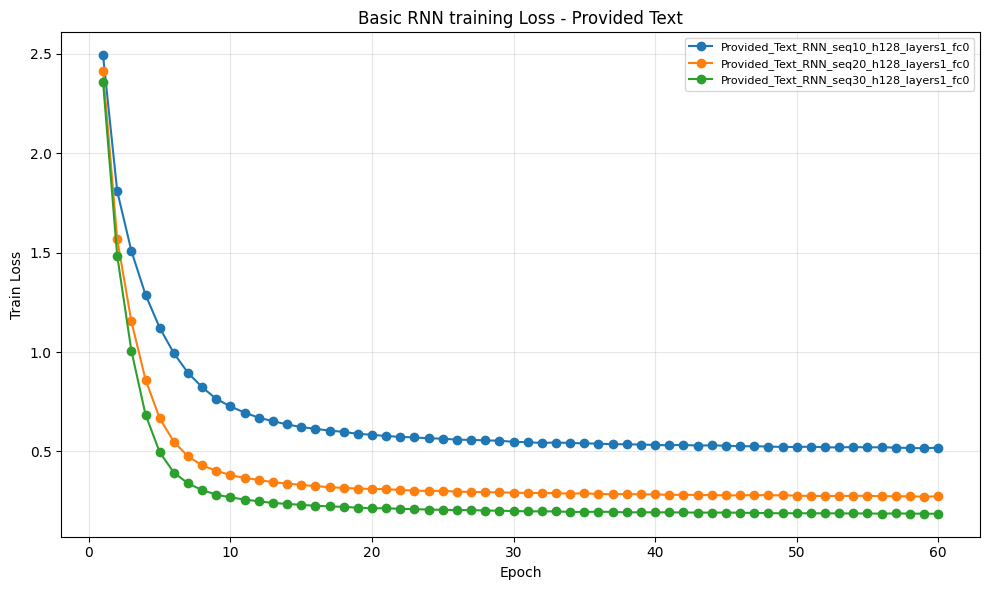

### Problem 1 - Basic RNN validation loss curves

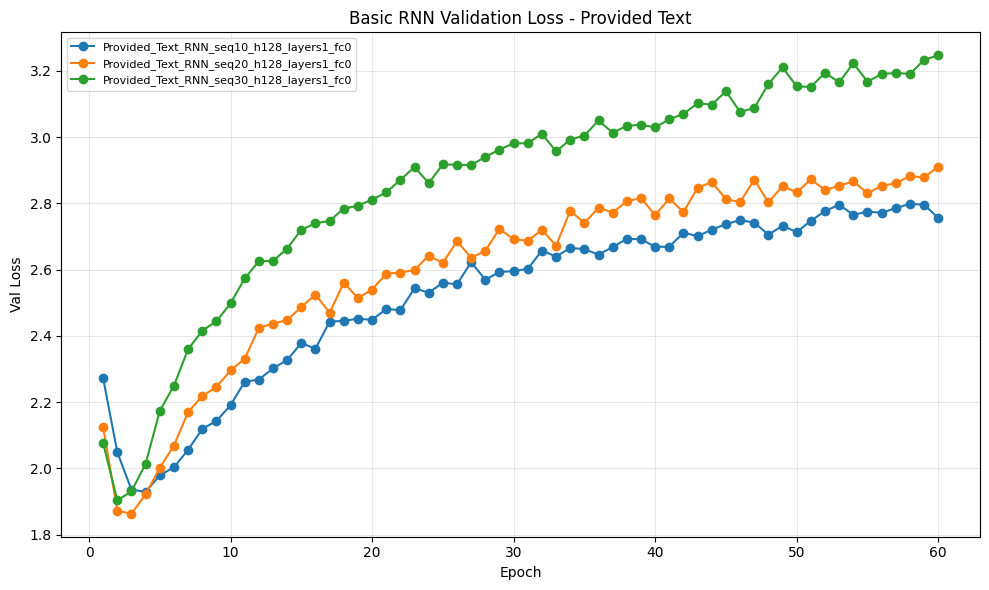

### Problem 1 - Basic RNN validation accuracy curves

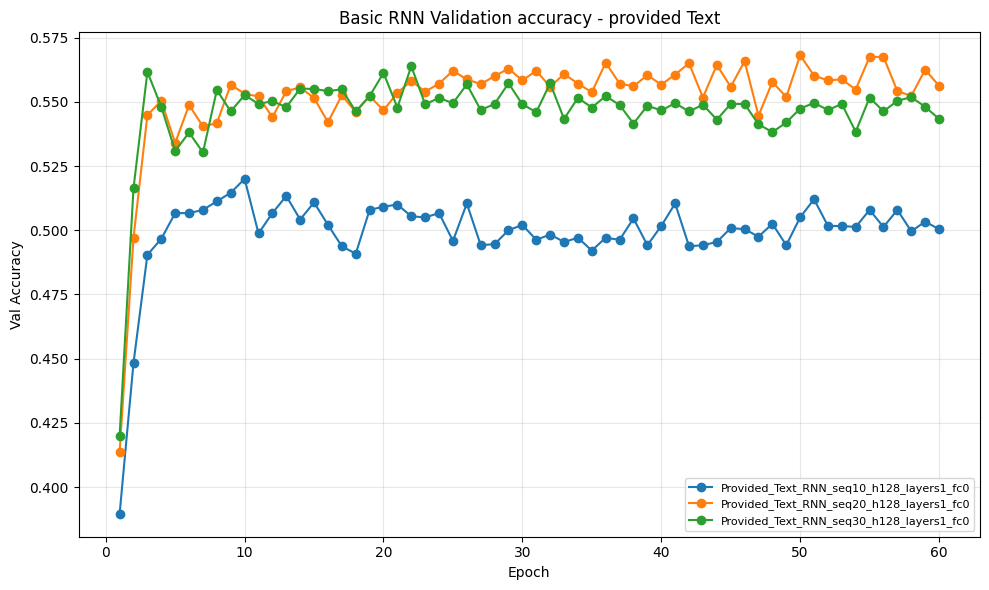

### Problem 1 - Basic RNN model size by sequence length

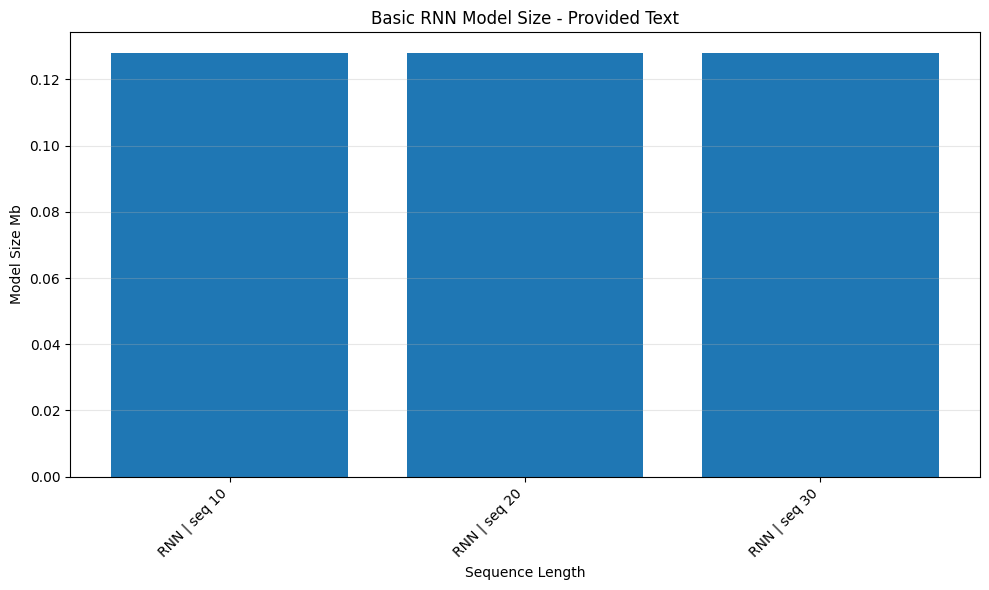

### Problem 1 - Basic RNN generated text samples

#### Provided_Text_RNN_seq10_h128_layers1_fc0

```text
Next character prediction of the next character in a given sequence of text and predictions and the next character prediction involves feeding it large amounts of text auto-completion features, and even in the field of natural language process, the models or deep learning al
```

#### Provided_Text_RNN_seq20_h128_layers1_fc0

```text
Next character prediction involves the use of Recurrent Neural Networks (RNNs), and more specifically, a various applications, making text-based chatbots and virtual assistants.

In summary, next character prediction is a fundamental task in the field of natural language pro
```

#### Provided_Text_RNN_seq30_h128_layers1_fc0

```text
Next character prediction involves the use of Recurrent Neural Networks (RNNs), and more specifically, a variant called Long Short-Term Memory (LSTM) networks. RNNs are particularly well-suited for sequential data like text, as they can maintain information in 'memory' about
```

In [16]:
# ============================================================
# 5. Problem 1 plots and results
# ============================================================

print_section("Problem 1 - Basic RNN result table")
display_clean_results(p1_rnn_results_df)

print_section("Problem 1 - Basic RNN training loss curves")
plot_training_curves(
    p1_rnn_histories,
    title="Basic RNN training Loss - Provided Text",
    metric="train_loss",
    save_name="basic_rnn_training_loss.png",
)

print_section("Problem 1 - Basic RNN validation loss curves")
plot_training_curves(
    p1_rnn_histories,
    title="Basic RNN Validation Loss - Provided Text",
    metric="val_loss",
    save_name="basic_rnn_validation_loss.png",
)

print_section("Problem 1 - Basic RNN validation accuracy curves")
plot_training_curves(
    p1_rnn_histories,
    title="Basic RNN Validation accuracy - provided Text",
    metric="val_accuracy",
    save_name="basic_rnn_validation_accuracy.png",
)

print_section("Problem 1 - Basic RNN model size by sequence length")
plot_result_bar(
    p1_rnn_results_df,
    x_col="sequence_length",
    y_col="model_size_mb",
    group_col="model_type",
    title="Basic RNN Model Size - Provided Text",
    save_name="basic_rnn_model_size.png",
)

print_section("Problem 1 - Basic RNN generated text samples")
show_samples(p1_rnn_samples)

In [ ]:
# ============================================================
# 6A. Notebook Problem 2 - LSTM on provided paragraph (Official HW Problem 1)
# ============================================================

p2_lstm_fixed_results = []
p2_lstm_fixed_histories = []
p2_lstm_fixed_samples = []

for seq_len in FIXED_TEXT_SEQUENCE_LENGTHS:
    model, result_df, history_df, sample = run_single_experiment(
        text=NEXT_CHARACTER_TEXT,
        dataset_name="Provided Text",
        model_type="LSTM",
        seq_len=seq_len,
        epochs=FIXED_TEXT_EPOCHS,
        batch_size=FIXED_TEXT_BATCH_SIZE,
        embed_size=64,
        hidden_size=128,
        num_layers=1,
        fc_hidden_size=0,
        dropout=0.0,
        learning_rate=LEARNING_RATE,
        grad_clip=GRAD_CLIP,
        generate_chars=GENERATE_CHARS_FIXED_TEXT,
        start_text="Next character prediction",
    )

    p2_lstm_fixed_results.append(result_df)
    p2_lstm_fixed_histories.append(history_df)
    p2_lstm_fixed_samples.append(sample)

p2_lstm_fixed_results_df = pd.concat(p2_lstm_fixed_results, ignore_index=True)
p2_lstm_fixed_history_df = pd.concat(p2_lstm_fixed_histories, ignore_index=True)

save_results_csv(p2_lstm_fixed_results_df, "problem2_lstm_provided_text_results.csv")
save_results_csv(p2_lstm_fixed_history_df, "problem2_lstm_provided_text_history.csv")

display_clean_results(p2_lstm_fixed_results_df)

Dataset: Provided Text
Model: LSTM | seq_len=10 | embed=64 | hidden=128 | layers=1 | fc_hidden=0
Epoch 001/60 | train loss: 2.7273 | val loss: 2.3732 | val acc: 0.3588 | val ppl: 10.73
Epoch 002/60 | train loss: 1.9675 | val loss: 2.1062 | val acc: 0.4288 | val ppl: 8.22
Epoch 003/60 | train loss: 1.5900 | val loss: 1.9892 | val acc: 0.4754 | val ppl: 7.31
Epoch 004/60 | train loss: 1.3235 | val loss: 1.9152 | val acc: 0.5025 | val ppl: 6.79
Epoch 005/60 | train loss: 1.1192 | val loss: 1.9170 | val acc: 0.5138 | val ppl: 6.80
Epoch 006/60 | train loss: 0.9728 | val loss: 1.9474 | val acc: 0.5225 | val ppl: 7.01
Epoch 007/60 | train loss: 0.8635 | val loss: 1.9807 | val acc: 0.5292 | val ppl: 7.25
Epoch 008/60 | train loss: 0.7853 | val loss: 2.0048 | val acc: 0.5267 | val ppl: 7.42
Epoch 009/60 | train loss: 0.7284 | val loss: 2.0819 | val acc: 0.5192 | val ppl: 8.02
Epoch 010/60 | train loss: 0.6860 | val loss: 2.1098 | val acc: 0.5262 | val ppl: 8.25
Epoch 011/60 | train loss: 0.650

,dataset,model_type,sequence_length,embedding_size,hidden_size,num_layers,fc_hidden_size,final_train_loss,final_val_loss,final_val_accuracy,final_val_perplexity,training_time_sec,inference_time_sec,trainable_parameters,model_size_mb,approx_ops_per_sequence
0,Provided Text,LSTM,10,64,128,1,0,0.492500,2.806571,0.512500,16.553061,4.047806,0.126669,108013,0.412037,1040640
1,Provided Text,LSTM,20,64,128,1,0,0.257663,3.075028,0.517292,21.650498,4.064672,0.125014,108013,0.412037,2081280
2,Provided Text,LSTM,30,64,128,1,0,0.174311,3.144315,0.531944,23.203768,4.100124,0.125857,108013,0.412037,3121920


In [ ]:
# ============================================================
# 6B. Problem 2 - LSTM on Tiny Shakespeare
# ============================================================

tiny_shakespeare_text = load_tiny_shakespeare(max_chars=SHAKESPEARE_MAX_CHARS)

print("Tiny Shakespeare characters:", len(tiny_shakespeare_text))
print("Tiny Shakespeare vocabulary size:", len(set(tiny_shakespeare_text)))
print("First 300 characters:")
print(tiny_shakespeare_text[:300])


lstm_shakespeare_configs = [
    {
        "name": "LSTM_seq20_base",
        "seq_len": 20,
        "embed_size": 64,
        "hidden_size": 128,
        "num_layers": 1,
        "fc_hidden_size": 0,
        "dropout": 0.0,
    },
    {
        "name": "LSTM_seq30_base",
        "seq_len": 30,
        "embed_size": 64,
        "hidden_size": 128,
        "num_layers": 1,
        "fc_hidden_size": 0,
        "dropout": 0.0,
    },
    {
        "name": "LSTM_seq50_base",
        "seq_len": 50,
        "embed_size": 64,
        "hidden_size": 128,
        "num_layers": 1,
        "fc_hidden_size": 0,
        "dropout": 0.0,
    },
    {
        "name": "LSTM_seq30_smaller_hidden",
        "seq_len": 30,
        "embed_size": 64,
        "hidden_size": 64,
        "num_layers": 1,
        "fc_hidden_size": 0,
        "dropout": 0.0,
    },
    {
        "name": "LSTM_seq30_two_layers",
        "seq_len": 30,
        "embed_size": 64,
        "hidden_size": 128,
        "num_layers": 2,
        "fc_hidden_size": 0,
        "dropout": 0.2,
    },
    {
        "name": "LSTM_seq30_fc_head",
        "seq_len": 30,
        "embed_size": 64,
        "hidden_size": 128,
        "num_layers": 1,
        "fc_hidden_size": 128,
        "dropout": 0.0,
    },
]

p2_lstm_shakespeare_results = []
p2_lstm_shakespeare_histories = []
p2_lstm_shakespeare_samples = []

for cfg in lstm_shakespeare_configs:
    print_section(cfg["name"])

    model, result_df, history_df, sample = run_single_experiment(
        text=tiny_shakespeare_text,
        dataset_name="Tiny Shakespeare",
        model_type="LSTM",
        seq_len=cfg["seq_len"],
        epochs=SHAKESPEARE_EPOCHS,
        batch_size=SHAKESPEARE_BATCH_SIZE,
        embed_size=cfg["embed_size"],
        hidden_size=cfg["hidden_size"],
        num_layers=cfg["num_layers"],
        fc_hidden_size=cfg["fc_hidden_size"],
        dropout=cfg["dropout"],
        learning_rate=LEARNING_RATE,
        grad_clip=GRAD_CLIP,
        generate_chars=GENERATE_CHARS_SHAKESPEARE,
        start_text="ROMEO:",
    )

    result_df["config_description"] = cfg["name"]
    history_df["config_description"] = cfg["name"]
    sample["config_description"] = cfg["name"]

    p2_lstm_shakespeare_results.append(result_df)
    p2_lstm_shakespeare_histories.append(history_df)
    p2_lstm_shakespeare_samples.append(sample)

p2_lstm_shakespeare_results_df = pd.concat(p2_lstm_shakespeare_results, ignore_index=True)
p2_lstm_shakespeare_history_df = pd.concat(p2_lstm_shakespeare_histories, ignore_index=True)

save_results_csv(p2_lstm_shakespeare_results_df, "problem2_lstm_tiny_shakespeare_results.csv")
save_results_csv(p2_lstm_shakespeare_history_df, "problem2_lstm_tiny_shakespeare_history.csv")

display_clean_results(p2_lstm_shakespeare_results_df)

Tiny Shakespeare characters: 1115394
Tiny Shakespeare vocabulary size: 65
First 300 characters:
First Citizen:
Before we proceed any further, hear me speak.

All:
Speak, speak.

First Citizen:
You are all resolved rather to die than to famish?

All:
Resolved. resolved.

First Citizen:
First, you know Caius Marcius is chief enemy to the people.

All:
We know't, we know't.

First Citizen:
Let us


### LSTM_seq20_base

Dataset: Tiny Shakespeare
Model: LSTM | seq_len=20 | embed=64 | hidden=128 | layers=1 | fc_hidden=0
Epoch 001/10 | train loss: 1.6617 | val loss: 1.6978 | val acc: 0.4969 | val ppl: 5.46
Epoch 002/10 | train loss: 1.4868 | val loss: 1.6688 | val acc: 0.5069 | val ppl: 5.31
Epoch 003/10 | train loss: 1.4564 | val loss: 1.6601 | val acc: 0.5092 | val ppl: 5.26
Epoch 004/10 | train loss: 1.4409 | val loss: 1.6612 | val acc: 0.5115 | val ppl: 5.27
Epoch 005/10 | train loss: 1.4311 | val loss: 1.6642 | val acc: 0.5121 | val ppl: 5.28
Epoch 006/10 | train loss: 1.4240 | val loss: 1.6689 | val acc: 0.5120 | val ppl: 5.31
Epoch 007/10 | train loss: 1.4189 | val loss: 1.6679 | val acc: 0.5115 | val ppl: 5.30
Epoch 008/10 | train loss: 1.4148 | val loss: 1.6682 | val acc: 0.5142 | val ppl: 5.30
Epoch 009/10 | train loss: 1.4114 | val loss: 1.6700 | val acc: 0.5142 | val ppl: 5.31
Epoch 010/10 | train loss: 1.4086 | val loss: 1.6737 | val acc: 0.5125 | val ppl: 5.33

Generated sample:
ROMEO:
That

### LSTM_seq30_base

Dataset: Tiny Shakespeare
Model: LSTM | seq_len=30 | embed=64 | hidden=128 | layers=1 | fc_hidden=0
Epoch 001/10 | train loss: 1.6246 | val loss: 1.6608 | val acc: 0.5107 | val ppl: 5.26
Epoch 002/10 | train loss: 1.4335 | val loss: 1.6401 | val acc: 0.5170 | val ppl: 5.16
Epoch 003/10 | train loss: 1.4018 | val loss: 1.6410 | val acc: 0.5210 | val ppl: 5.16
Epoch 004/10 | train loss: 1.3860 | val loss: 1.6455 | val acc: 0.5213 | val ppl: 5.18
Epoch 005/10 | train loss: 1.3758 | val loss: 1.6496 | val acc: 0.5230 | val ppl: 5.21
Epoch 006/10 | train loss: 1.3687 | val loss: 1.6563 | val acc: 0.5233 | val ppl: 5.24
Epoch 007/10 | train loss: 1.3632 | val loss: 1.6619 | val acc: 0.5232 | val ppl: 5.27
Epoch 008/10 | train loss: 1.3592 | val loss: 1.6724 | val acc: 0.5232 | val ppl: 5.32
Epoch 009/10 | train loss: 1.3559 | val loss: 1.6704 | val acc: 0.5239 | val ppl: 5.31
Epoch 010/10 | train loss: 1.3531 | val loss: 1.6752 | val acc: 0.5230 | val ppl: 5.34

Generated sample:
ROMEO:
What

...

### LSTM_seq30_two_layers

Dataset: Tiny Shakespeare
Model: LSTM | seq_len=30 | embed=64 | hidden=128 | layers=2 | fc_hidden=0
Epoch 001/10 | train loss: 1.6327 | val loss: 1.6087 | val acc: 0.5208 | val ppl: 5.00
Epoch 002/10 | train loss: 1.4385 | val loss: 1.5946 | val acc: 0.5274 | val ppl: 4.93
Epoch 003/10 | train loss: 1.4089 | val loss: 1.5883 | val acc: 0.5293 | val ppl: 4.90
Epoch 004/10 | train loss: 1.3940 | val loss: 1.5896 | val acc: 0.5321 | val ppl: 4.90
Epoch 005/10 | train loss: 1.3845 | val loss: 1.5805 | val acc: 0.5322 | val ppl: 4.86
Epoch 006/10 | train loss: 1.3780 | val loss: 1.5874 | val acc: 0.5317 | val ppl: 4.89
Epoch 007/10 | train loss: 1.3731 | val loss: 1.5854 | val acc: 0.5319 | val ppl: 4.88
Epoch 008/10 | train loss: 1.3692 | val loss: 1.5835 | val acc: 0.5337 | val ppl: 4.87
Epoch 009/10 | train loss: 1.3659 | val loss: 1.5837 | val acc: 0.5317 | val ppl: 4.87
Epoch 010/10 | train loss: 1.3634 | val loss: 1.5824 | val acc: 0.5332 | val ppl: 4.87

Generated sample:
ROMEO:
'Tis

### LSTM_seq30_fc_head

Dataset: Tiny Shakespeare
Model: LSTM | seq_len=30 | embed=64 | hidden=128 | layers=1 | fc_hidden=128
Epoch 001/10 | train loss: 1.5584 | val loss: 1.6561 | val acc: 0.5178 | val ppl: 5.24
Epoch 002/10 | train loss: 1.3884 | val loss: 1.6551 | val acc: 0.5226 | val ppl: 5.23
Epoch 003/10 | train loss: 1.3571 | val loss: 1.6610 | val acc: 0.5238 | val ppl: 5.26
Epoch 004/10 | train loss: 1.3402 | val loss: 1.6766 | val acc: 0.5231 | val ppl: 5.35
Epoch 005/10 | train loss: 1.3294 | val loss: 1.6839 | val acc: 0.5230 | val ppl: 5.39
Epoch 006/10 | train loss: 1.3215 | val loss: 1.6901 | val acc: 0.5233 | val ppl: 5.42
Epoch 007/10 | train loss: 1.3158 | val loss: 1.6984 | val acc: 0.5219 | val ppl: 5.47
Epoch 008/10 | train loss: 1.3114 | val loss: 1.6920 | val acc: 0.5251 | val ppl: 5.43
Epoch 009/10 | train loss: 1.3076 | val loss: 1.7025 | val acc: 0.5236 | val ppl: 5.49
Epoch 010/10 | train loss: 1.3047 | val loss: 1.7006 | val acc: 0.5240 | val ppl: 5.48

Generated sample:
ROMEO:
Hi

,dataset,model_type,sequence_length,embedding_size,hidden_size,num_layers,fc_hidden_size,final_train_loss,final_val_loss,final_val_accuracy,final_val_perplexity,training_time_sec,inference_time_sec,trainable_parameters,model_size_mb,approx_ops_per_sequence
0,Tiny Shakespeare,LSTM,20,64,128,1,0,1.408550,1.673675,0.512472,5.331725,71.172834,0.432840,111873,0.426762,2132480
3,Tiny Shakespeare,LSTM,30,64,64,1,0,1.512735,1.733700,0.499253,5.661564,70.851092,0.151742,41665,0.158939,1107840
1,Tiny Shakespeare,LSTM,30,64,128,1,0,1.353119,1.675177,0.522989,5.339740,72.508646,0.367741,111873,0.426762,3198720
5,Tiny Shakespeare,LSTM,30,64,128,1,128,1.304747,1.700598,0.524040,5.477220,75.469431,0.376018,128385,0.489750,3690240
4,Tiny Shakespeare,LSTM,30,64,128,2,0,1.363384,1.582417,0.533166,4.866706,88.641188,0.639143,243969,0.930668,7130880
2,Tiny Shakespeare,LSTM,50,64,128,1,0,1.294236,1.658390,0.529108,5.250850,80.596546,0.366469,111873,0.426762,5331200


### LSTM provided text result table

,dataset,model_type,sequence_length,embedding_size,hidden_size,num_layers,fc_hidden_size,final_train_loss,final_val_loss,final_val_accuracy,final_val_perplexity,training_time_sec,inference_time_sec,trainable_parameters,model_size_mb,approx_ops_per_sequence
0,Provided Text,LSTM,10,64,128,1,0,0.492500,2.806571,0.512500,16.553061,4.047806,0.126669,108013,0.412037,1040640
1,Provided Text,LSTM,20,64,128,1,0,0.257663,3.075028,0.517292,21.650498,4.064672,0.125014,108013,0.412037,2081280
2,Provided Text,LSTM,30,64,128,1,0,0.174311,3.144315,0.531944,23.203768,4.100124,0.125857,108013,0.412037,3121920


### LSTM provided text training loss

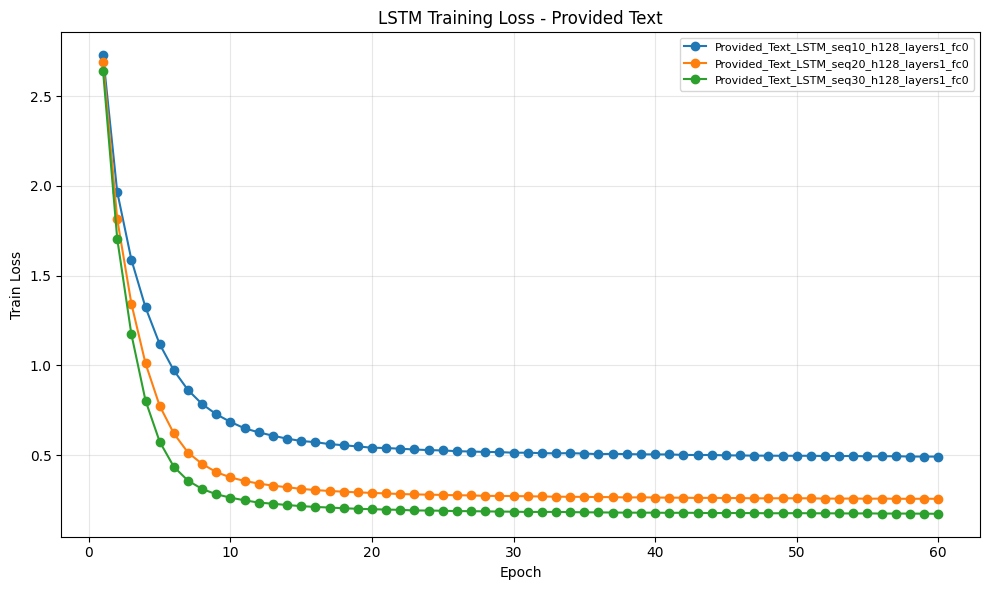

### LSTM provided text validation accuracy

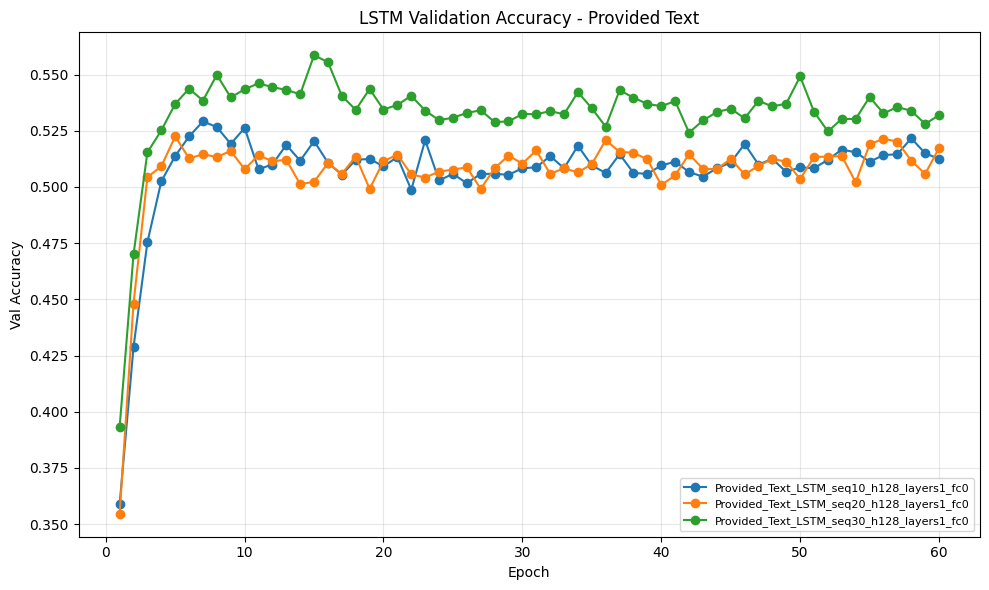

### LSTM generated samples on provided text

#### Provided_Text_LSTM_seq10_h128_layers1_fc0

```text
Next character prediction involves prediction tasks.

Training a sequence of character prediction involves feeding it large amounts of text data, allowing a sequence of character prediction tasks.

Training a sequence of character is most likely to follow. These prediction i
```

#### Provided_Text_LSTM_seq20_h128_layers1_fc0

```text
Next character prediction plays a crucial role in enhancing the capabilities of various NLP applications, making text-based ith character prediction is a fundamental task in the field of natural language processing (NLP) that involves predicting the next character prediction
```

#### Provided_Text_LSTM_seq30_h128_layers1_fc0

```text
Next character prediction involves the use of Recurrent Neural Networks (RNNs), and more specifically, a variant called Long Short-Term Memory (LSTM) networks. RNNs are particularly well-suited for sequential data like text, as they can maintain information in 'memory' about
```

### LSTM Tiny Shakespeare result table

,dataset,model_type,sequence_length,embedding_size,hidden_size,num_layers,fc_hidden_size,final_train_loss,final_val_loss,final_val_accuracy,final_val_perplexity,training_time_sec,inference_time_sec,trainable_parameters,model_size_mb,approx_ops_per_sequence
0,Tiny Shakespeare,LSTM,20,64,128,1,0,1.408550,1.673675,0.512472,5.331725,71.172834,0.432840,111873,0.426762,2132480
3,Tiny Shakespeare,LSTM,30,64,64,1,0,1.512735,1.733700,0.499253,5.661564,70.851092,0.151742,41665,0.158939,1107840
1,Tiny Shakespeare,LSTM,30,64,128,1,0,1.353119,1.675177,0.522989,5.339740,72.508646,0.367741,111873,0.426762,3198720
5,Tiny Shakespeare,LSTM,30,64,128,1,128,1.304747,1.700598,0.524040,5.477220,75.469431,0.376018,128385,0.489750,3690240
4,Tiny Shakespeare,LSTM,30,64,128,2,0,1.363384,1.582417,0.533166,4.866706,88.641188,0.639143,243969,0.930668,7130880
2,Tiny Shakespeare,LSTM,50,64,128,1,0,1.294236,1.658390,0.529108,5.250850,80.596546,0.366469,111873,0.426762,5331200


### LSTM Tiny Shakespeare training loss

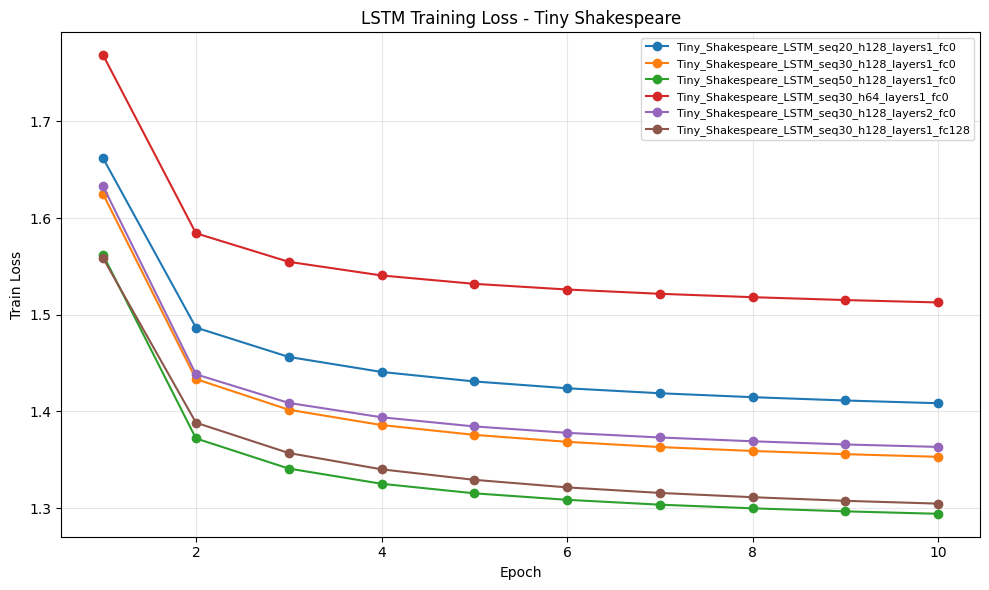

### LSTM Tiny Shakespeare validation loss

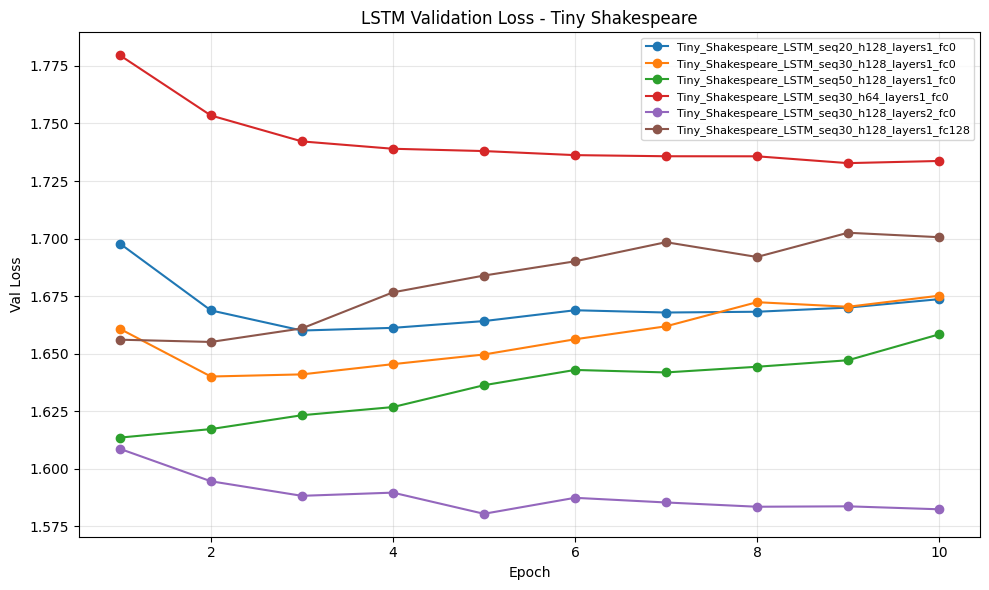

### LSTM Tiny Shakespeare validation accuracy

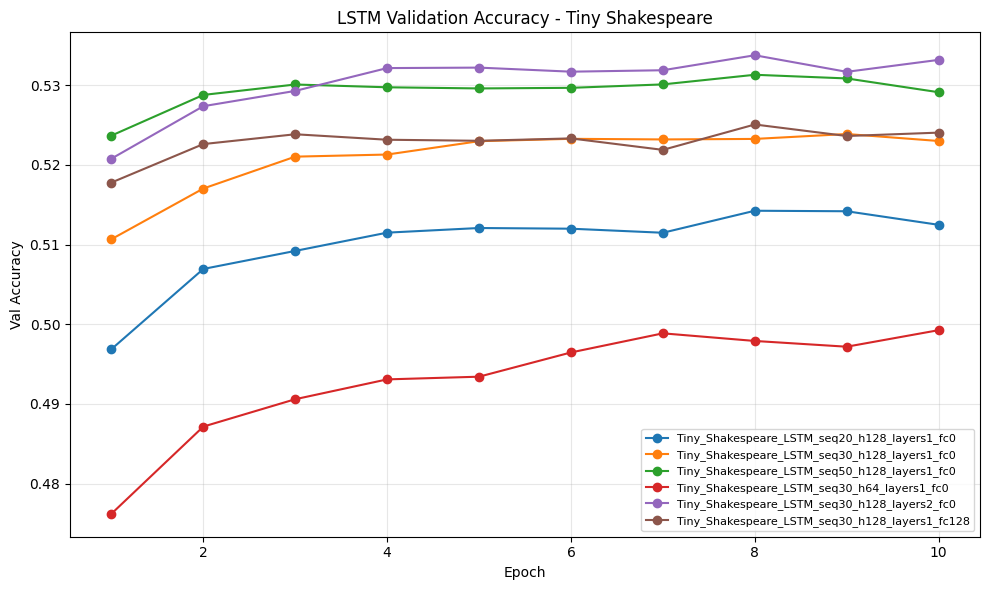

### LSTM Tiny Shakespeare perplexity

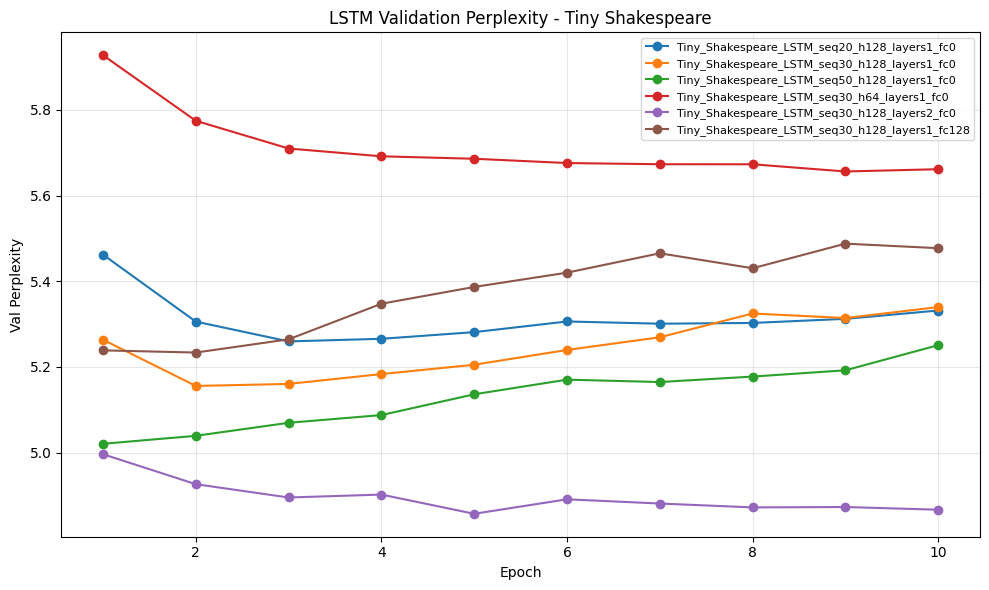

### LSTM Tiny Shakespeare model size

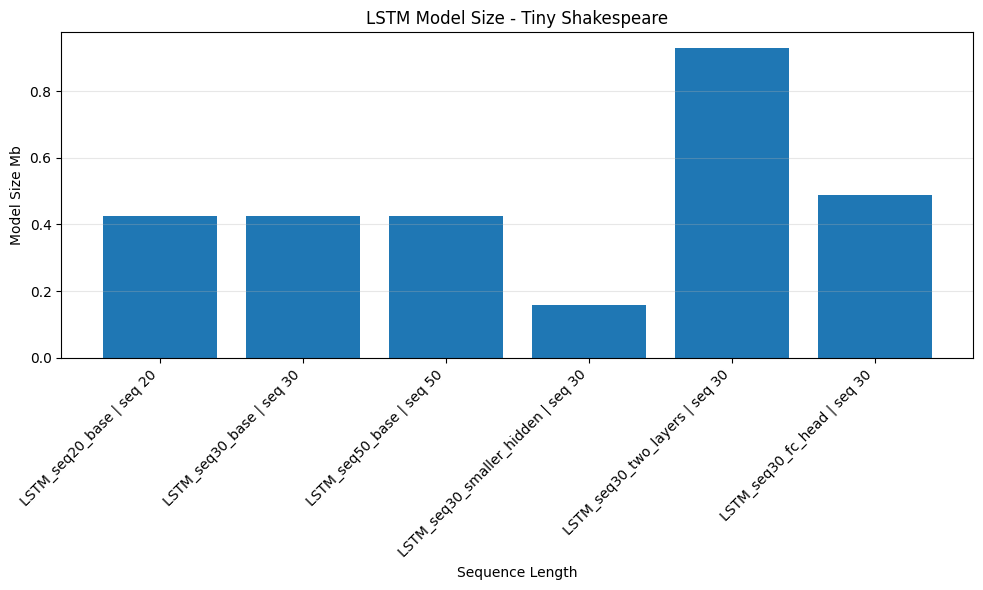

### LSTM Tiny Shakespeare training time

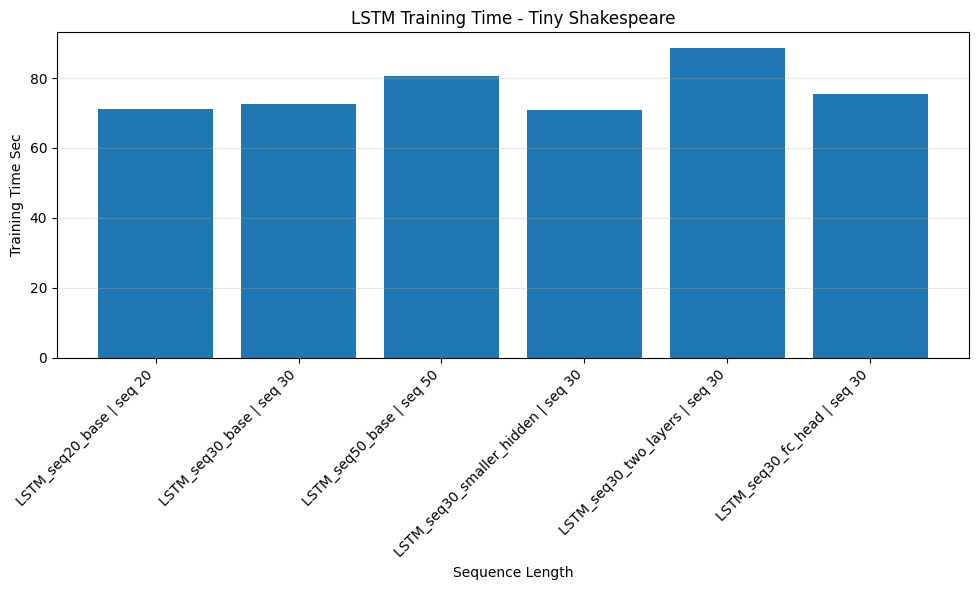

### LSTM generated Shakespeare samples

#### Tiny_Shakespeare_LSTM_seq20_h128_layers1_fc0

```text
ROMEO:
That's some a child on the noble good sons:
And if I do make before the king, which should not thou hear
That may tell you, then I wish the truth.

QUEEN ELIZABETH:
God kill'd both the unto the pursuin the boy: I'll compare to lives to keep me,
Which thus to my death?
Or you in injurce to your brother's
must pity for the Sicils of this life
That may speak of usurper redoubled man?

Second Was above you that
Before the daffody perforelves from a name in heaven have to show us with that was in th
```

#### Tiny_Shakespeare_LSTM_seq30_h128_layers1_fc0

```text
ROMEO:
What husband, curse me to him?

MENENIUS:
I be not help it.

FRIAR LAURENCE:
A ningrating frowns,
Becomes court this credit in the ends what me at a while up, and atils for pity.

VIRGILIA:
Will you say and the care to hide thee the mind to the best.

KING RICHARD III:
How, see he shall come her to the cause,
To Pates, friend himself call him forth our satisfore him me be mine.

KING HENRY VI:
The sea go to keep those suspire to hear me to the world?
And in hians, for this intelligence to find 
```

#### Tiny_Shakespeare_LSTM_seq50_h128_layers1_fc0

```text
ROMEO:
O, then we born to be person bound thereof
To tell thee and sour children I'll find his wit took the services
and blessed the duck of thy noble as the fair and conqueiture pardon
That 'twere for't to me distrain to him!

MENENIUS:
Peace, we will bear her children flesh,
And though Clarence make it the green too, ever!

POMPEY:
My lord, yet what is a peace.

NORTHUMBERLAND:
Harp more that we of me to fetch thy news? how should
Show me alone: I am nothing can sighs, the says, all me.

First Lord:
```

#### Tiny_Shakespeare_LSTM_seq30_h64_layers1_fc0

```text
ROMEO:
They not, since to her the luit: all wonting, to this way the father, I have consent if we kneephard, my villans of the very
To company find, in Cronted of your more the pevisure and where I cannot dreams!
Why, I proud; but need, and this lord, they are we so, which that, if knowlight is to have have reveness the blood
'Tis their glove, I will not perget be late no man again: near more, we be power his breaks you made
With you, sir, my man of love live to a husband, the valon.

MERCUTIO:
Cousit
```

#### Tiny_Shakespeare_LSTM_seq30_h128_layers2_fc0

```text
ROMEO:
'Tis thrown those instrument.

HENRY PERCY:
Marry, be play; he is
A pity, sirs, that come, whose threw o'er him.

BUCKINGHAM:
Bastings to my sir; one that thou wast's content
That party ow thy love to our head, which on your pale
part, is the mind and let's have lay thy both warm is the fairest privilege of death.
If but the trial her head and could follow the duke for thee.

WARWICK:
Pronounce our time and that I read itself that will live it, you could not have
so once with the nurse of York;
```

#### Tiny_Shakespeare_LSTM_seq30_h128_layers1_fc128

```text
ROMEO:
His wife, know the yoke and that is a ballad and tear for the
base subjects to see her nurse, who hath the place will take we for my pains, and with the great blood,
Contidam sheep-sheartory of your grace's brow.
And'liety give me hurl me spelior with please. I am more
That Bolingbroke I met my son is hearing preserved.

KATHARINA:
I thank your crimes; so dancly himself beseech you, for his personace
That woman, give me suitors are has not spoke from me more,
Come, lords, they do not do remain 
```

In [17]:
# ============================================================
# 7. Problem 2 plots and results
# ============================================================

print_section("LSTM provided text result table")
display_clean_results(p2_lstm_fixed_results_df)

print_section("LSTM provided text training loss")
plot_training_curves(
    p2_lstm_fixed_histories,
    title="LSTM Training Loss - Provided Text",
    metric="train_loss",
    save_name="lstm_provided_training_loss.png",
)

print_section("LSTM provided text validation accuracy")
plot_training_curves(
    p2_lstm_fixed_histories,
    title="LSTM Validation Accuracy - Provided Text",
    metric="val_accuracy",
    save_name="lstm_provided_validation_accuracy.png",
)

print_section("LSTM generated samples on provided text")
show_samples(p2_lstm_fixed_samples)

print_section("LSTM Tiny Shakespeare result table")
display_clean_results(p2_lstm_shakespeare_results_df)

print_section("LSTM Tiny Shakespeare training loss")
plot_training_curves(
    p2_lstm_shakespeare_histories,
    title="LSTM Training Loss - Tiny Shakespeare",
    metric="train_loss",
    save_name="lstm_shakespeare_training_loss.png",
)

print_section("LSTM Tiny Shakespeare validation loss")
plot_training_curves(
    p2_lstm_shakespeare_histories,
    title="LSTM Validation Loss - Tiny Shakespeare",
    metric="val_loss",
    save_name="lstm_shakespeare_validation_loss.png",
)

print_section("LSTM Tiny Shakespeare validation accuracy")
plot_training_curves(
    p2_lstm_shakespeare_histories,
    title="LSTM Validation Accuracy - Tiny Shakespeare",
    metric="val_accuracy",
    save_name="lstm_shakespeare_validation_accuracy.png",
)

print_section("LSTM Tiny Shakespeare perplexity")
plot_training_curves(
    p2_lstm_shakespeare_histories,
    title="LSTM Validation Perplexity - Tiny Shakespeare",
    metric="val_perplexity",
    save_name="lstm_shakespeare_perplexity.png",
)

print_section("LSTM Tiny Shakespeare model size")
plot_result_bar(
    p2_lstm_shakespeare_results_df,
    x_col="sequence_length",
    y_col="model_size_mb",
    group_col="config_description",
    title="LSTM Model Size - Tiny Shakespeare",
    save_name="lstm_shakespeare_model_size.png",
)

print_section("LSTM Tiny Shakespeare training time")
plot_result_bar(
    p2_lstm_shakespeare_results_df,
    x_col="sequence_length",
    y_col="training_time_sec",
    group_col="config_description",
    title="LSTM Training Time - Tiny Shakespeare",
    save_name="lstm_shakespeare_training_time.png",
)

print_section("LSTM generated Shakespeare samples")
show_samples(p2_lstm_shakespeare_samples)

In [ ]:
# ============================================================
# 8A. Problem 3 - GRU on provided paragraph
# ============================================================

p3_gru_fixed_results = []
p3_gru_fixed_histories = []
p3_gru_fixed_samples = []

for seq_len in FIXED_TEXT_SEQUENCE_LENGTHS:
    model, result_df, history_df, sample = run_single_experiment(
        text=NEXT_CHARACTER_TEXT,
        dataset_name="Provided Text",
        model_type="GRU",
        seq_len=seq_len,
        epochs=FIXED_TEXT_EPOCHS,
        batch_size=FIXED_TEXT_BATCH_SIZE,
        embed_size=64,
        hidden_size=128,
        num_layers=1,
        fc_hidden_size=0,
        dropout=0.0,
        learning_rate=LEARNING_RATE,
        grad_clip=GRAD_CLIP,
        generate_chars=GENERATE_CHARS_FIXED_TEXT,
        start_text="Next character prediction",
    )

    p3_gru_fixed_results.append(result_df)
    p3_gru_fixed_histories.append(history_df)
    p3_gru_fixed_samples.append(sample)

p3_gru_fixed_results_df = pd.concat(p3_gru_fixed_results, ignore_index=True)
p3_gru_fixed_history_df = pd.concat(p3_gru_fixed_histories, ignore_index=True)

save_results_csv(p3_gru_fixed_results_df, "problem3_gru_provided_text_results.csv")
save_results_csv(p3_gru_fixed_history_df, "problem3_gru_provided_text_history.csv")

display_clean_results(p3_gru_fixed_results_df)

Dataset: Provided Text
Model: GRU | seq_len=10 | embed=64 | hidden=128 | layers=1 | fc_hidden=0
Epoch 001/60 | train loss: 2.6145 | val loss: 2.3124 | val acc: 0.3646 | val ppl: 10.10
Epoch 002/60 | train loss: 1.8240 | val loss: 2.0534 | val acc: 0.4575 | val ppl: 7.79
Epoch 003/60 | train loss: 1.4219 | val loss: 1.9479 | val acc: 0.4829 | val ppl: 7.01
Epoch 004/60 | train loss: 1.1387 | val loss: 1.9867 | val acc: 0.4954 | val ppl: 7.29
Epoch 005/60 | train loss: 0.9457 | val loss: 2.0332 | val acc: 0.5038 | val ppl: 7.64
Epoch 006/60 | train loss: 0.8185 | val loss: 2.1423 | val acc: 0.4979 | val ppl: 8.52
Epoch 007/60 | train loss: 0.7388 | val loss: 2.2316 | val acc: 0.4900 | val ppl: 9.31
Epoch 008/60 | train loss: 0.6825 | val loss: 2.2475 | val acc: 0.5042 | val ppl: 9.46
Epoch 009/60 | train loss: 0.6443 | val loss: 2.3504 | val acc: 0.4967 | val ppl: 10.49
Epoch 010/60 | train loss: 0.6174 | val loss: 2.3696 | val acc: 0.5038 | val ppl: 10.69
Epoch 011/60 | train loss: 0.59

,dataset,model_type,sequence_length,embedding_size,hidden_size,num_layers,fc_hidden_size,final_train_loss,final_val_loss,final_val_accuracy,final_val_perplexity,training_time_sec,inference_time_sec,trainable_parameters,model_size_mb,approx_ops_per_sequence
0,Provided Text,GRU,10,64,128,1,0,0.490221,3.064150,0.504583,21.416240,3.942943,0.066295,83181,0.31731,794880
1,Provided Text,GRU,20,64,128,1,0,0.255412,3.059160,0.556250,21.309644,3.921281,0.065132,83181,0.31731,1589760
2,Provided Text,GRU,30,64,128,1,0,0.173011,3.287042,0.529306,26.763581,3.926763,0.065575,83181,0.31731,2384640


In [ ]:
# ============================================================
# 8B.Problem 3 - GRU on Tiny Shakespeare
# ============================================================

if "tiny_shakespeare_text" not in globals():
    tiny_shakespeare_text = load_tiny_shakespeare(max_chars=SHAKESPEARE_MAX_CHARS)



gru_shakespeare_configs = [
    {
        "name": "GRU_seq20_base",
        "seq_len": 20,
        "embed_size": 64,
        "hidden_size": 128,
        "num_layers": 1,
        "fc_hidden_size": 0,
        "dropout": 0.0,
    },
    {
        "name": "GRU_seq30_base",
        "seq_len": 30,
        "embed_size": 64,
        "hidden_size": 128,
        "num_layers": 1,
        "fc_hidden_size": 0,
        "dropout": 0.0,
    },
    {
        "name": "GRU_seq50_base",
        "seq_len": 50,
        "embed_size": 64,
        "hidden_size": 128,
        "num_layers": 1,
        "fc_hidden_size": 0,
        "dropout": 0.0,
    },
    {
        "name": "GRU_seq30_smaller_hidden",
        "seq_len": 30,
        "embed_size": 64,
        "hidden_size": 64,
        "num_layers": 1,
        "fc_hidden_size": 0,
        "dropout": 0.0,
    },
    {
        "name": "GRU_seq30_two_layers",
        "seq_len": 30,
        "embed_size": 64,
        "hidden_size": 128,
        "num_layers": 2,
        "fc_hidden_size": 0,
        "dropout": 0.2,
    },
    {
        "name": "GRU_seq30_fc_head",
        "seq_len": 30,
        "embed_size": 64,
        "hidden_size": 128,
        "num_layers": 1,
        "fc_hidden_size": 128,
        "dropout": 0.0,
    },
]

p3_gru_shakespeare_results = []
p3_gru_shakespeare_histories = []
p3_gru_shakespeare_samples = []

for cfg in gru_shakespeare_configs:
    print_section(cfg["name"])

    model, result_df, history_df, sample = run_single_experiment(
        text=tiny_shakespeare_text,
        dataset_name="Tiny Shakespeare",
        model_type="GRU",
        seq_len=cfg["seq_len"],
        epochs=SHAKESPEARE_EPOCHS,
        batch_size=SHAKESPEARE_BATCH_SIZE,
        embed_size=cfg["embed_size"],
        hidden_size=cfg["hidden_size"],
        num_layers=cfg["num_layers"],
        fc_hidden_size=cfg["fc_hidden_size"],
        dropout=cfg["dropout"],
        learning_rate=LEARNING_RATE,
        grad_clip=GRAD_CLIP,
        generate_chars=GENERATE_CHARS_SHAKESPEARE,
        start_text="ROMEO:",
    )

    result_df["config_description"] = cfg["name"]
    history_df["config_description"] = cfg["name"]
    sample["config_description"] = cfg["name"]

    p3_gru_shakespeare_results.append(result_df)
    p3_gru_shakespeare_histories.append(history_df)
    p3_gru_shakespeare_samples.append(sample)

p3_gru_shakespeare_results_df = pd.concat(p3_gru_shakespeare_results, ignore_index=True)
p3_gru_shakespeare_history_df = pd.concat(p3_gru_shakespeare_histories, ignore_index=True)

save_results_csv(p3_gru_shakespeare_results_df, "problem3_gru_tiny_shakespeare_results.csv")
save_results_csv(p3_gru_shakespeare_history_df, "problem3_gru_tiny_shakespeare_history.csv")

display_clean_results(p3_gru_shakespeare_results_df)

### GRU_seq20_base

Dataset: Tiny Shakespeare
Model: GRU | seq_len=20 | embed=64 | hidden=128 | layers=1 | fc_hidden=0
Epoch 001/10 | train loss: 1.6355 | val loss: 1.6995 | val acc: 0.4967 | val ppl: 5.47
Epoch 002/10 | train loss: 1.4976 | val loss: 1.6841 | val acc: 0.5010 | val ppl: 5.39
Epoch 003/10 | train loss: 1.4772 | val loss: 1.6790 | val acc: 0.5049 | val ppl: 5.36
Epoch 004/10 | train loss: 1.4670 | val loss: 1.6743 | val acc: 0.5067 | val ppl: 5.33
Epoch 005/10 | train loss: 1.4607 | val loss: 1.6795 | val acc: 0.5043 | val ppl: 5.36
Epoch 006/10 | train loss: 1.4562 | val loss: 1.6743 | val acc: 0.5093 | val ppl: 5.33
Epoch 007/10 | train loss: 1.4527 | val loss: 1.6780 | val acc: 0.5071 | val ppl: 5.35
Epoch 008/10 | train loss: 1.4500 | val loss: 1.6752 | val acc: 0.5065 | val ppl: 5.34
Epoch 009/10 | train loss: 1.4476 | val loss: 1.6772 | val acc: 0.5071 | val ppl: 5.35
Epoch 010/10 | train loss: 1.4458 | val loss: 1.6779 | val acc: 0.5076 | val ppl: 5.35

Generated sample:
ROMEO:
There

### GRU_seq30_base

Dataset: Tiny Shakespeare
Model: GRU | seq_len=30 | embed=64 | hidden=128 | layers=1 | fc_hidden=0
Epoch 001/10 | train loss: 1.5801 | val loss: 1.6645 | val acc: 0.5113 | val ppl: 5.28
Epoch 002/10 | train loss: 1.4423 | val loss: 1.6525 | val acc: 0.5143 | val ppl: 5.22
Epoch 003/10 | train loss: 1.4226 | val loss: 1.6494 | val acc: 0.5176 | val ppl: 5.20
Epoch 004/10 | train loss: 1.4126 | val loss: 1.6501 | val acc: 0.5159 | val ppl: 5.21
Epoch 005/10 | train loss: 1.4063 | val loss: 1.6487 | val acc: 0.5163 | val ppl: 5.20
Epoch 006/10 | train loss: 1.4017 | val loss: 1.6530 | val acc: 0.5165 | val ppl: 5.22
Epoch 007/10 | train loss: 1.3985 | val loss: 1.6536 | val acc: 0.5191 | val ppl: 5.23
Epoch 008/10 | train loss: 1.3959 | val loss: 1.6585 | val acc: 0.5173 | val ppl: 5.25
Epoch 009/10 | train loss: 1.3939 | val loss: 1.6580 | val acc: 0.5184 | val ppl: 5.25
Epoch 010/10 | train loss: 1.3922 | val loss: 1.6605 | val acc: 0.5173 | val ppl: 5.26

Generated sample:
ROMEO:
No mo

### GRU_seq50_base

...

### GRU_seq30_two_layers

Dataset: Tiny Shakespeare
Model: GRU | seq_len=30 | embed=64 | hidden=128 | layers=2 | fc_hidden=0
Epoch 001/10 | train loss: 1.5817 | val loss: 1.5978 | val acc: 0.5205 | val ppl: 4.94
Epoch 002/10 | train loss: 1.4523 | val loss: 1.5850 | val acc: 0.5269 | val ppl: 4.88
Epoch 003/10 | train loss: 1.4339 | val loss: 1.5830 | val acc: 0.5273 | val ppl: 4.87
Epoch 004/10 | train loss: 1.4244 | val loss: 1.5826 | val acc: 0.5283 | val ppl: 4.87
Epoch 005/10 | train loss: 1.4183 | val loss: 1.5822 | val acc: 0.5275 | val ppl: 4.87
Epoch 006/10 | train loss: 1.4139 | val loss: 1.5825 | val acc: 0.5283 | val ppl: 4.87
Epoch 007/10 | train loss: 1.4106 | val loss: 1.5800 | val acc: 0.5290 | val ppl: 4.86
Epoch 008/10 | train loss: 1.4079 | val loss: 1.5850 | val acc: 0.5281 | val ppl: 4.88
Epoch 009/10 | train loss: 1.4057 | val loss: 1.5807 | val acc: 0.5297 | val ppl: 4.86
Epoch 010/10 | train loss: 1.4038 | val loss: 1.5800 | val acc: 0.5285 | val ppl: 4.85

Generated sample:
ROMEO:
O mag

### GRU_seq30_fc_head

Dataset: Tiny Shakespeare
Model: GRU | seq_len=30 | embed=64 | hidden=128 | layers=1 | fc_hidden=128
Epoch 001/10 | train loss: 1.5357 | val loss: 1.6642 | val acc: 0.5170 | val ppl: 5.28
Epoch 002/10 | train loss: 1.3958 | val loss: 1.6740 | val acc: 0.5208 | val ppl: 5.33
Epoch 003/10 | train loss: 1.3733 | val loss: 1.6785 | val acc: 0.5222 | val ppl: 5.36
Epoch 004/10 | train loss: 1.3618 | val loss: 1.6834 | val acc: 0.5242 | val ppl: 5.38
Epoch 005/10 | train loss: 1.3545 | val loss: 1.6905 | val acc: 0.5256 | val ppl: 5.42
Epoch 006/10 | train loss: 1.3493 | val loss: 1.7000 | val acc: 0.5211 | val ppl: 5.47
Epoch 007/10 | train loss: 1.3455 | val loss: 1.7001 | val acc: 0.5249 | val ppl: 5.47
Epoch 008/10 | train loss: 1.3426 | val loss: 1.7009 | val acc: 0.5246 | val ppl: 5.48
Epoch 009/10 | train loss: 1.3403 | val loss: 1.6990 | val acc: 0.5256 | val ppl: 5.47
Epoch 010/10 | train loss: 1.3382 | val loss: 1.7070 | val acc: 0.5250 | val ppl: 5.51

Generated sample:
ROMEO:
Why

,dataset,model_type,sequence_length,embedding_size,hidden_size,num_layers,fc_hidden_size,final_train_loss,final_val_loss,final_val_accuracy,final_val_perplexity,training_time_sec,inference_time_sec,trainable_parameters,model_size_mb,approx_ops_per_sequence
0,Tiny Shakespeare,GRU,20,64,128,1,0,1.445822,1.677889,0.507574,5.354240,69.933018,0.164197,87041,0.332035,1640960
3,Tiny Shakespeare,GRU,30,64,64,1,0,1.560297,1.783960,0.486235,5.953384,69.581094,0.135900,33345,0.127201,862080
1,Tiny Shakespeare,GRU,30,64,128,1,0,1.392165,1.660514,0.517280,5.262015,69.732312,0.162349,87041,0.332035,2461440
5,Tiny Shakespeare,GRU,30,64,128,1,128,1.338169,1.707020,0.525007,5.512509,73.388258,0.171707,103553,0.395023,2952960
4,Tiny Shakespeare,GRU,30,64,128,2,0,1.403830,1.579962,0.528453,4.854773,76.103962,0.248079,186113,0.709965,5410560
2,Tiny Shakespeare,GRU,50,64,128,1,0,1.336810,1.650375,0.527821,5.208931,70.854570,0.162233,87041,0.332035,4102400


### GRU provided text result table

,dataset,model_type,sequence_length,embedding_size,hidden_size,num_layers,fc_hidden_size,final_train_loss,final_val_loss,final_val_accuracy,final_val_perplexity,training_time_sec,inference_time_sec,trainable_parameters,model_size_mb,approx_ops_per_sequence
0,Provided Text,GRU,10,64,128,1,0,0.490221,3.064150,0.504583,21.416240,3.942943,0.066295,83181,0.31731,794880
1,Provided Text,GRU,20,64,128,1,0,0.255412,3.059160,0.556250,21.309644,3.921281,0.065132,83181,0.31731,1589760
2,Provided Text,GRU,30,64,128,1,0,0.173011,3.287042,0.529306,26.763581,3.926763,0.065575,83181,0.31731,2384640


### GRU provided text training loss

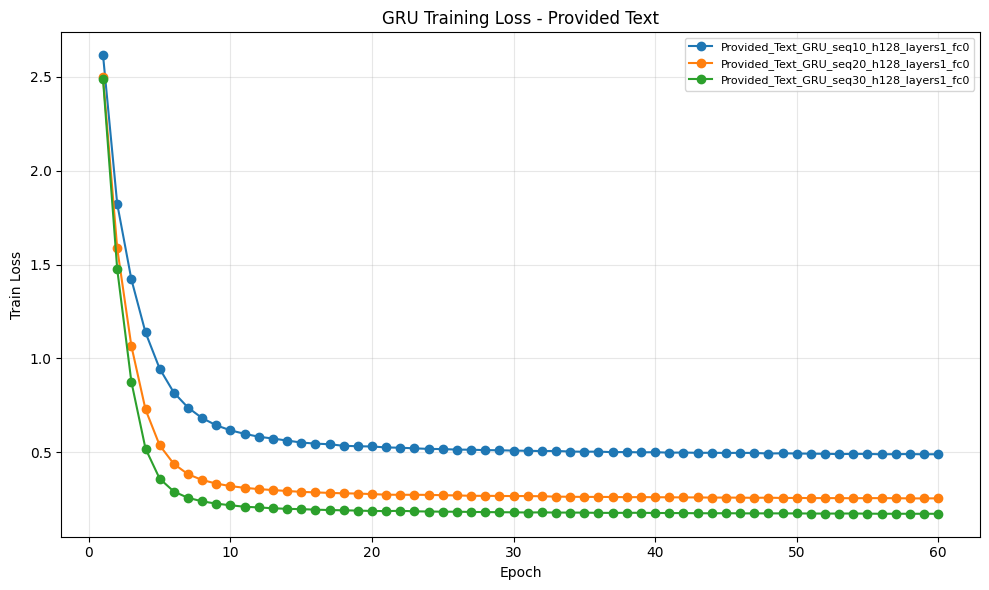

### GRU provided text validation accuracy

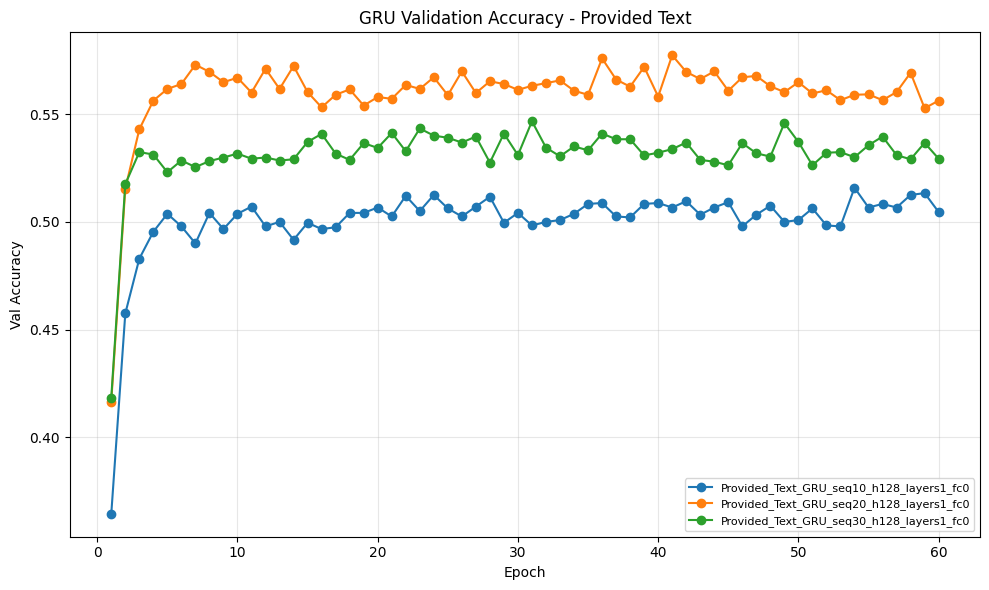

### GRU generated samples on provided text

#### Provided_Text_GRU_seq10_h128_layers1_fc0

```text
Next character predictions and the actual outcomes, thus improving its prediction of the model.

One of the most popular approaches to next character prediction involves predictive accuracy over time.

Once trained, the model adjusts its parameters to minimize the difference
```

#### Provided_Text_GRU_seq20_h128_layers1_fc0

```text
Next character prediction involves feeding it large amounts of text data, allowing it to learn the prediction of the next character prediction involves feeding it large amounts of text data, allowing it to learn the probability of each character's appearance following a sequ
```

#### Provided_Text_GRU_seq30_h128_layers1_fc0

```text
Next character prediction involves the use of Recurrent Neural Networks (RNNs), and more specifically, a variant called Long Short-Term Memory (LSTM) networks. RNNs are particularly well-suited for sequential data like text, as they can maintain information in 'memory' about
```

### GRU Tiny Shakespeare result table

,dataset,model_type,sequence_length,embedding_size,hidden_size,num_layers,fc_hidden_size,final_train_loss,final_val_loss,final_val_accuracy,final_val_perplexity,training_time_sec,inference_time_sec,trainable_parameters,model_size_mb,approx_ops_per_sequence
0,Tiny Shakespeare,GRU,20,64,128,1,0,1.445822,1.677889,0.507574,5.354240,69.933018,0.164197,87041,0.332035,1640960
3,Tiny Shakespeare,GRU,30,64,64,1,0,1.560297,1.783960,0.486235,5.953384,69.581094,0.135900,33345,0.127201,862080
1,Tiny Shakespeare,GRU,30,64,128,1,0,1.392165,1.660514,0.517280,5.262015,69.732312,0.162349,87041,0.332035,2461440
5,Tiny Shakespeare,GRU,30,64,128,1,128,1.338169,1.707020,0.525007,5.512509,73.388258,0.171707,103553,0.395023,2952960
4,Tiny Shakespeare,GRU,30,64,128,2,0,1.403830,1.579962,0.528453,4.854773,76.103962,0.248079,186113,0.709965,5410560
2,Tiny Shakespeare,GRU,50,64,128,1,0,1.336810,1.650375,0.527821,5.208931,70.854570,0.162233,87041,0.332035,4102400


### GRU Tiny Shakespeare training loss

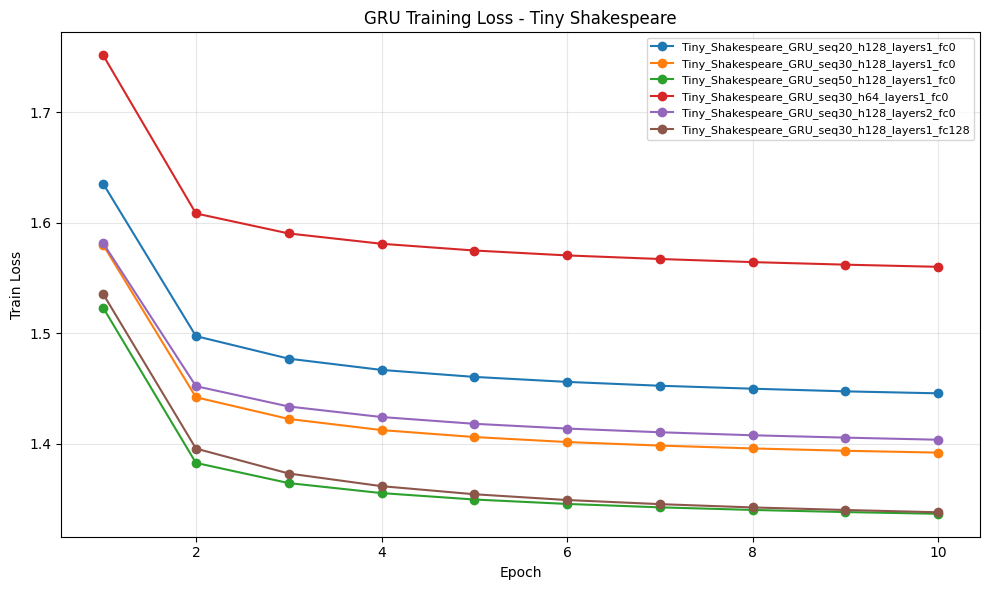

### GRU Tiny Shakespeare validation loss

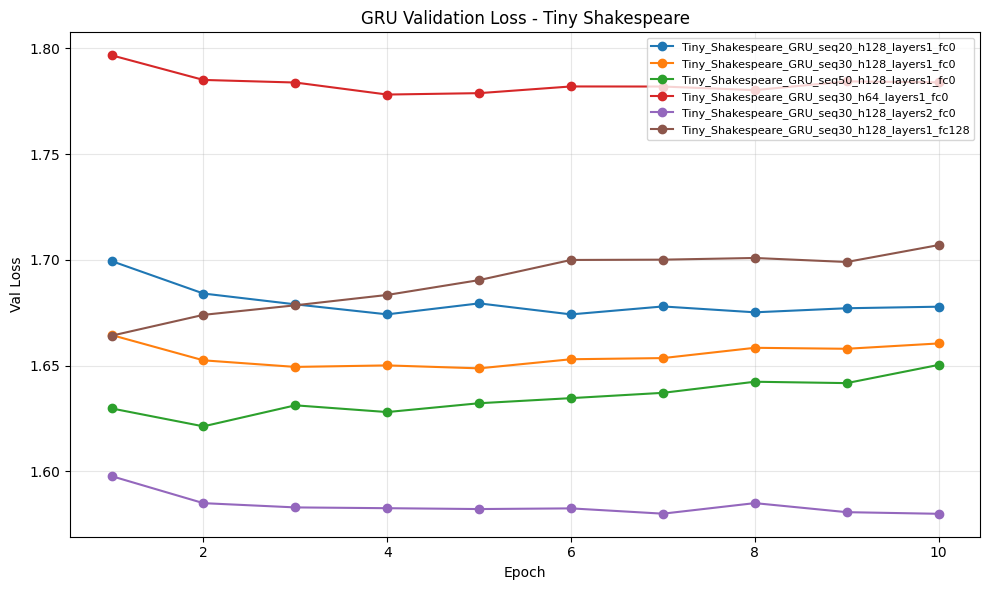

### GRU Tiny Shakespeare validation accuracy

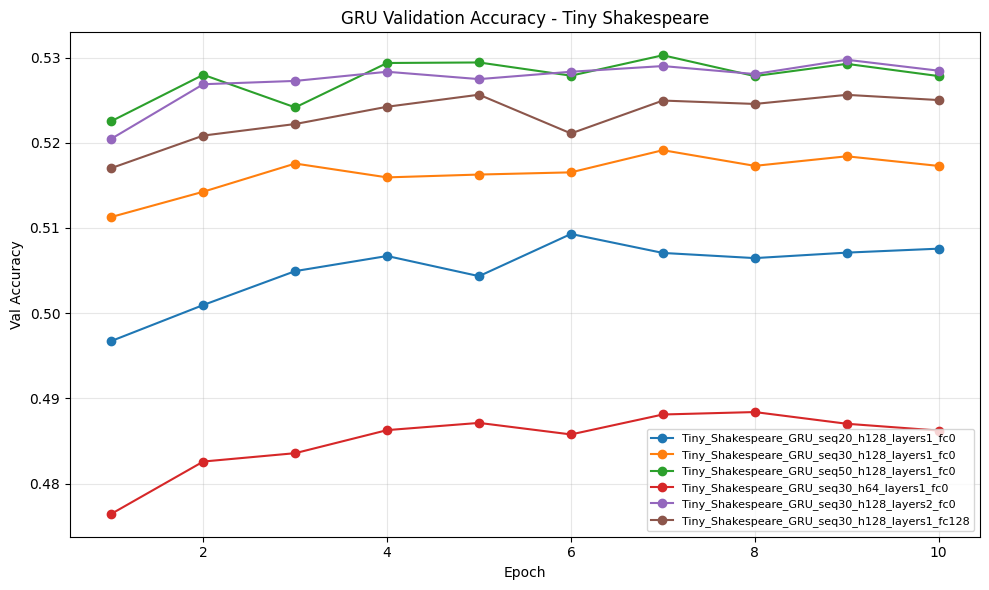

### GRU Tiny Shakespeare perplexity

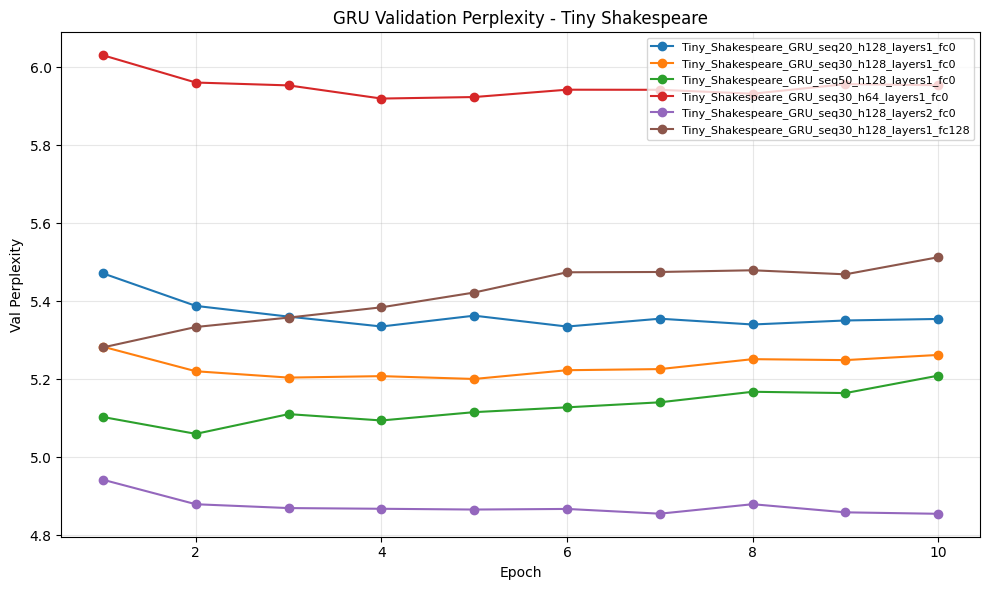

### GRU Tiny Shakespeare model size

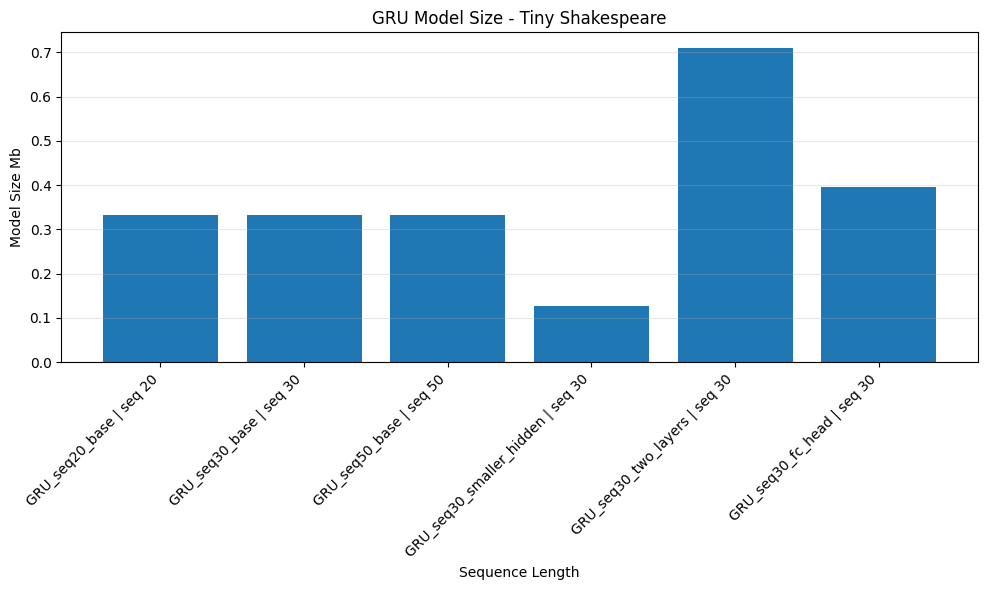

### GRU Tiny Shakespeare training time

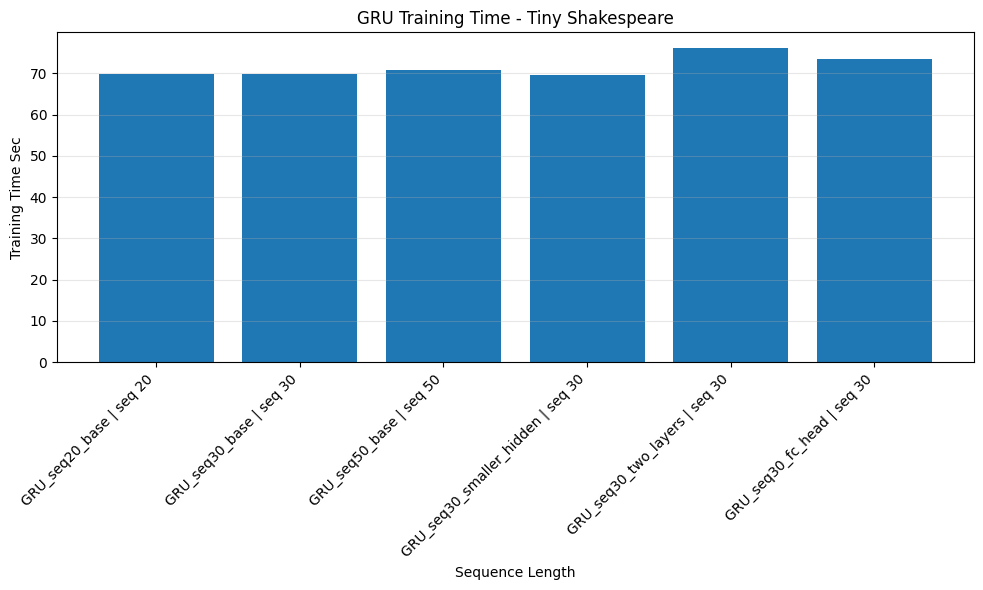

### GRU generated Shakespeare samples

#### Tiny_Shakespeare_GRU_seq20_h128_layers1_fc0

```text
ROMEO:
Therefore idly then.

CAPULET:
A grant:
And therefore, nor so, sir, and he beseech you avove
And now, the gods to be so, you for you comes. Go hither with Caius will went become to colour with the strifest tale to save his purpose; now us.

FRIAR LAURENCE:
Go in breath, he would was the way,
Till I all the loath that the rage to lady!

ELBOW:
If your unroot, when the farewell: not of his brone of God!

Second Mortion:
Standon my life,
From the servant: reply how so the nack, and now them, for t
```

#### Tiny_Shakespeare_GRU_seq30_h128_layers1_fc0

```text
ROMEO:
No more greathed with thy such a dispant this coronable the night me sent to question
Even any imity,
Why all thy wits for a lady pent to your prince!
Come, sir! he was here, my silk by the name me,
With the chamber,
There is treason as respect and to my brother is call my sister's way to so: but they that would you have partly past there, be contract you, sir; i' thy moners can see it did all the morning his homers that love of you show you
As I show.

LADY ANNE:
Ay, the king.

LADY ANNE:
Go b
```

#### Tiny_Shakespeare_GRU_seq50_h128_layers1_fc0

```text
ROMEO:
Are the prison: if have a saint:
I know it must not come too lord, you have said;
And there is a lord, is Catesby:
I thank us an hour and lie again,
And she had no more fortune for Rome,
And had she bose prepared with strew herself:
You have not previct foul't:
An usants doft and the Christian tots having the manners
And hold the people, more, madam.
See for heaven death for the crown
With that batting, good myst in night should that we trone.
Thou art fair brother, and stir: take before me but
```

#### Tiny_Shakespeare_GRU_seq30_h64_layers1_fc0

```text
ROMEO:
I metve, hear the
The honour be speak take it your gifery comfort staps,
And both.

QUEEN MARGARET:
All parts of thee of the send our out me to it, this whose down:
For the power,
Our slander heaven'd on wash hath chaicher same the pursess aip peace, but breakes with here of this gold, what on the eyous natry,
Thrust I would else the son and her, and the dour them stand beat ready the heaven gentleman:
So my twift, and sight you to in their last the dencuted might in brated most;
And comous Pea
```

#### Tiny_Shakespeare_GRU_seq30_h128_layers2_fc0

```text
ROMEO:
O magly, may a king, cut: she is he make ye to the charged of fair mother's dead,
Detrellex; or I prive for the Bohemis to death of this and shall go spread to proud.

KING RICHARD III:
Marry, my lord.

KING RICHARD III:
Will you hear thee? and how my love,
Musician that thy poor Bohemia.

MENENIUS:
I think, and therefore, let's hear our brother Edward, as he the wing.
Deck, what are the land, it were it in his grave,
In my friendly had been to the people. I
am an Romeo should bables the crown 
```

#### Tiny_Shakespeare_GRU_seq30_h128_layers1_fc128

```text
ROMEO:
Why, sir, my lord, as you speak and king of princess
To be come.

QUEEN MARGARET:
Thanks to-morrow by you sprave;
Or any ship; forbear will make thee no man? what had so farewell.

LUCIO:
Villain, to deaths. Additors were a father's like a time
That a world's grace me heaven for the fires their name:
To Romeo had he resign him.

JULIET:
So seem rhther from his life as it is fardel the nation comes would prove upon this bloody well-disprising?

ROMEO:
So haste hath been years that I will dispatc
```

In [20]:
# ============================================================
# 9. Problem 3 plots and results
# ============================================================

print_section("GRU provided text result table")
display_clean_results(p3_gru_fixed_results_df)

print_section("GRU provided text training loss")
plot_training_curves(
    p3_gru_fixed_histories,
    title="GRU Training Loss - Provided Text",
    metric="train_loss",
    save_name="gru_provided_training_loss.png",
)

print_section("GRU provided text validation accuracy")
plot_training_curves(
    p3_gru_fixed_histories,
    title="GRU Validation Accuracy - Provided Text",
    metric="val_accuracy",
    save_name="gru_provided_validation_accuracy.png",
)

print_section("GRU generated samples on provided text")
show_samples(p3_gru_fixed_samples)

print_section("GRU Tiny Shakespeare result table")
display_clean_results(p3_gru_shakespeare_results_df)

print_section("GRU Tiny Shakespeare training loss")
plot_training_curves(
    p3_gru_shakespeare_histories,
    title="GRU Training Loss - Tiny Shakespeare",
    metric="train_loss",
    save_name="gru_shakespeare_training_loss.png",
)

print_section("GRU Tiny Shakespeare validation loss")
plot_training_curves(
    p3_gru_shakespeare_histories,
    title="GRU Validation Loss - Tiny Shakespeare",
    metric="val_loss",
    save_name="gru_shakespeare_validation_loss.png",
)

print_section("GRU Tiny Shakespeare validation accuracy")
plot_training_curves(
    p3_gru_shakespeare_histories,
    title="GRU Validation Accuracy - Tiny Shakespeare",
    metric="val_accuracy",
    save_name="gru_shakespeare_validation_accuracy.png",
)

print_section("GRU Tiny Shakespeare perplexity")
plot_training_curves(
    p3_gru_shakespeare_histories,
    title="GRU Validation Perplexity - Tiny Shakespeare",
    metric="val_perplexity",
    save_name="gru_shakespeare_perplexity.png",
)

print_section("GRU Tiny Shakespeare model size")
plot_result_bar(
    p3_gru_shakespeare_results_df,
    x_col="sequence_length",
    y_col="model_size_mb",
    group_col="config_description",
    title="GRU Model Size - Tiny Shakespeare",
    save_name="gru_shakespeare_model_size.png",
)

print_section("GRU Tiny Shakespeare training time")
plot_result_bar(
    p3_gru_shakespeare_results_df,
    x_col="sequence_length",
    y_col="training_time_sec",
    group_col="config_description",
    title="GRU Training Time - Tiny Shakespeare",
    save_name="gru_shakespeare_training_time.png",
)

print_section("GRU generated Shakespeare samples")
show_samples(p3_gru_shakespeare_samples)

### Final combined result table

,dataset,model_type,sequence_length,embedding_size,hidden_size,num_layers,fc_hidden_size,final_train_loss,final_val_loss,final_val_accuracy,final_val_perplexity,training_time_sec,inference_time_sec,trainable_parameters,model_size_mb,approx_ops_per_sequence
6,Provided Text,GRU,10,64,128,1,0,0.490221,3.064150,0.504583,21.416240,3.942943,0.066295,83181,0.317310,794880
7,Provided Text,GRU,20,64,128,1,0,0.255412,3.059160,0.556250,21.309644,3.921281,0.065132,83181,0.317310,1589760
8,Provided Text,GRU,30,64,128,1,0,0.173011,3.287042,0.529306,26.763581,3.926763,0.065575,83181,0.317310,2384640
3,Provided Text,LSTM,10,64,128,1,0,0.492500,2.806571,0.512500,16.553061,4.047806,0.126669,108013,0.412037,1040640
4,Provided Text,LSTM,20,64,128,1,0,0.257663,3.075028,0.517292,21.650498,4.064672,0.125014,108013,0.412037,2081280
5,Provided Text,LSTM,30,64,128,1,0,0.174311,3.144315,0.531944,23.203768,4.100124,0.125857,108013,0.412037,3121920
0,Provided Text,RNN,10,64,128,1,0,0.519695,2.755376,0.500417,15.726946,4.644834,0.174232,33517,0.127857,303360
1,Provided Text,RNN,20,64,128,1,0,0.274615,2.910769,0.556250,18.370914,3.702814,0.054844,33517,0.127857,606720
2,Provided Text,RNN,30,64,128,1,0,0.186928,3.246676,0.543333,25.704748,3.696915,0.054806,33517,0.127857,910080
15,Tiny Shakespeare,GRU,20,64,128,1,0,1.445822,1.677889,0.507574,5.354240,69.933018,0.164197,87041,0.332035,1640960


### comparison: Provided Text, RNN vs LSTM vs GRU

,dataset,model_type,sequence_length,embedding_size,hidden_size,num_layers,fc_hidden_size,final_train_loss,final_val_loss,final_val_accuracy,final_val_perplexity,training_time_sec,inference_time_sec,trainable_parameters,model_size_mb,approx_ops_per_sequence
6,Provided Text,GRU,10,64,128,1,0,0.490221,3.064150,0.504583,21.416240,3.942943,0.066295,83181,0.317310,794880
7,Provided Text,GRU,20,64,128,1,0,0.255412,3.059160,0.556250,21.309644,3.921281,0.065132,83181,0.317310,1589760
8,Provided Text,GRU,30,64,128,1,0,0.173011,3.287042,0.529306,26.763581,3.926763,0.065575,83181,0.317310,2384640
3,Provided Text,LSTM,10,64,128,1,0,0.492500,2.806571,0.512500,16.553061,4.047806,0.126669,108013,0.412037,1040640
4,Provided Text,LSTM,20,64,128,1,0,0.257663,3.075028,0.517292,21.650498,4.064672,0.125014,108013,0.412037,2081280
5,Provided Text,LSTM,30,64,128,1,0,0.174311,3.144315,0.531944,23.203768,4.100124,0.125857,108013,0.412037,3121920
0,Provided Text,RNN,10,64,128,1,0,0.519695,2.755376,0.500417,15.726946,4.644834,0.174232,33517,0.127857,303360
1,Provided Text,RNN,20,64,128,1,0,0.274615,2.910769,0.556250,18.370914,3.702814,0.054844,33517,0.127857,606720
2,Provided Text,RNN,30,64,128,1,0,0.186928,3.246676,0.543333,25.704748,3.696915,0.054806,33517,0.127857,910080


### comparison: Tiny Shakespeare, LSTM vs GRU

,dataset,model_type,sequence_length,embedding_size,hidden_size,num_layers,fc_hidden_size,final_train_loss,final_val_loss,final_val_accuracy,final_val_perplexity,training_time_sec,inference_time_sec,trainable_parameters,model_size_mb,approx_ops_per_sequence
15,Tiny Shakespeare,GRU,20,64,128,1,0,1.445822,1.677889,0.507574,5.354240,69.933018,0.164197,87041,0.332035,1640960
18,Tiny Shakespeare,GRU,30,64,64,1,0,1.560297,1.783960,0.486235,5.953384,69.581094,0.135900,33345,0.127201,862080
16,Tiny Shakespeare,GRU,30,64,128,1,0,1.392165,1.660514,0.517280,5.262015,69.732312,0.162349,87041,0.332035,2461440
20,Tiny Shakespeare,GRU,30,64,128,1,128,1.338169,1.707020,0.525007,5.512509,73.388258,0.171707,103553,0.395023,2952960
19,Tiny Shakespeare,GRU,30,64,128,2,0,1.403830,1.579962,0.528453,4.854773,76.103962,0.248079,186113,0.709965,5410560
17,Tiny Shakespeare,GRU,50,64,128,1,0,1.336810,1.650375,0.527821,5.208931,70.854570,0.162233,87041,0.332035,4102400
9,Tiny Shakespeare,LSTM,20,64,128,1,0,1.408550,1.673675,0.512472,5.331725,71.172834,0.432840,111873,0.426762,2132480
12,Tiny Shakespeare,LSTM,30,64,64,1,0,1.512735,1.733700,0.499253,5.661564,70.851092,0.151742,41665,0.158939,1107840
10,Tiny Shakespeare,LSTM,30,64,128,1,0,1.353119,1.675177,0.522989,5.339740,72.508646,0.367741,111873,0.426762,3198720
14,Tiny Shakespeare,LSTM,30,64,128,1,128,1.304747,1.700598,0.524040,5.477220,75.469431,0.376018,128385,0.489750,3690240


### validation accuracy comparison

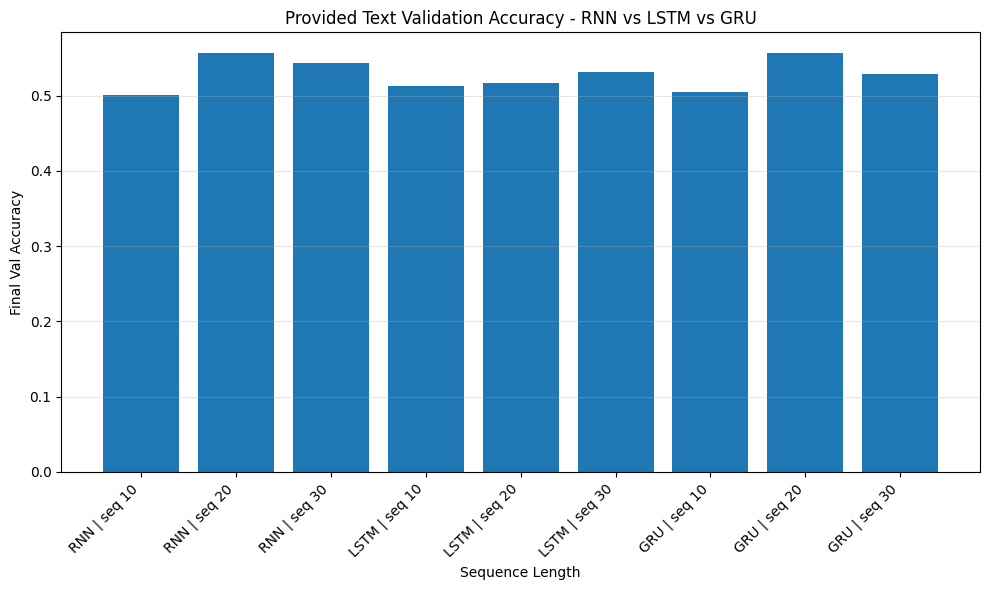

### Final Problem 1 training loss comparison

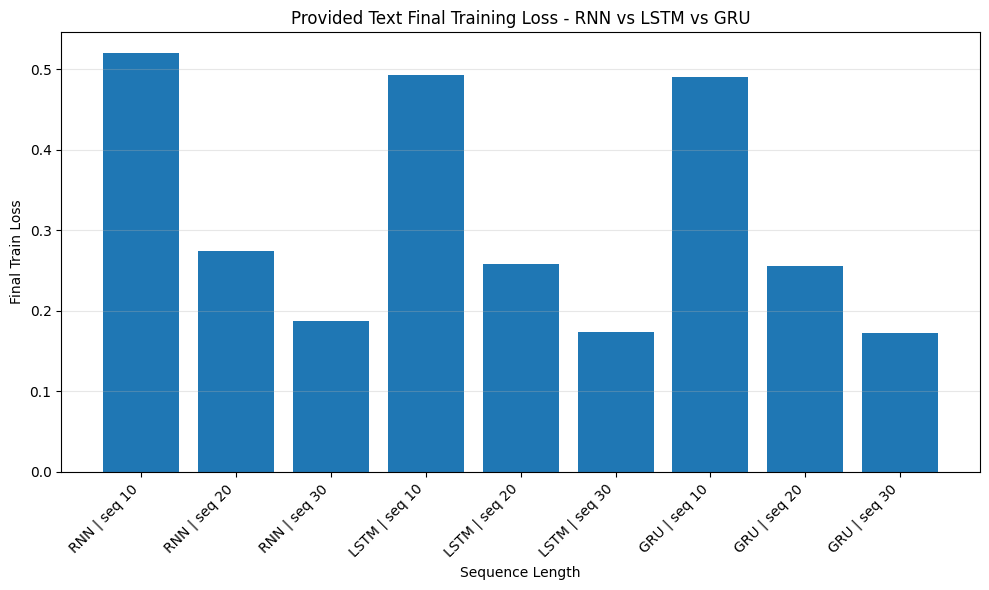

### Final Problem 1 model size comparison

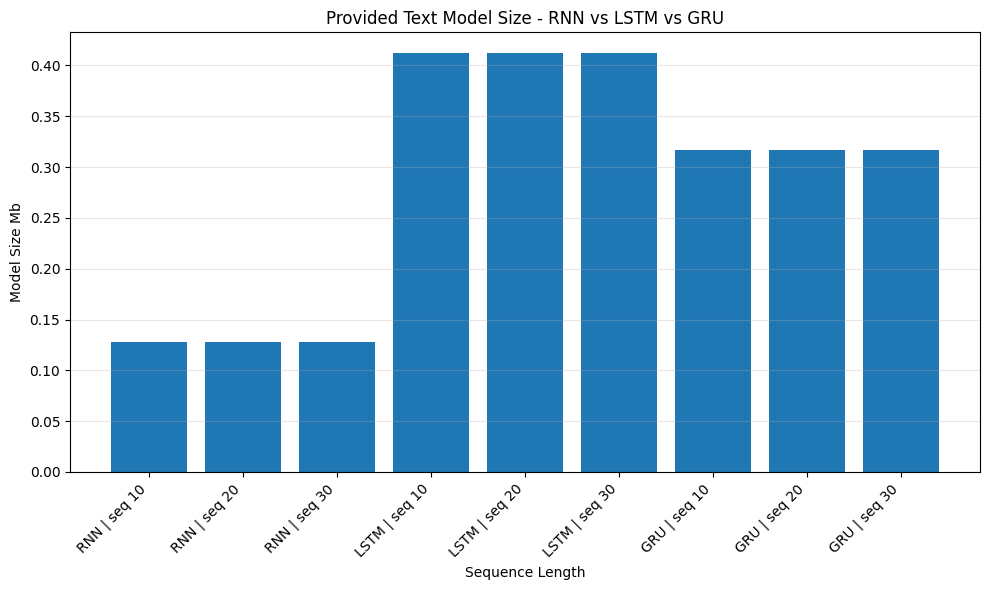

### Final Problem 1 training time comparison

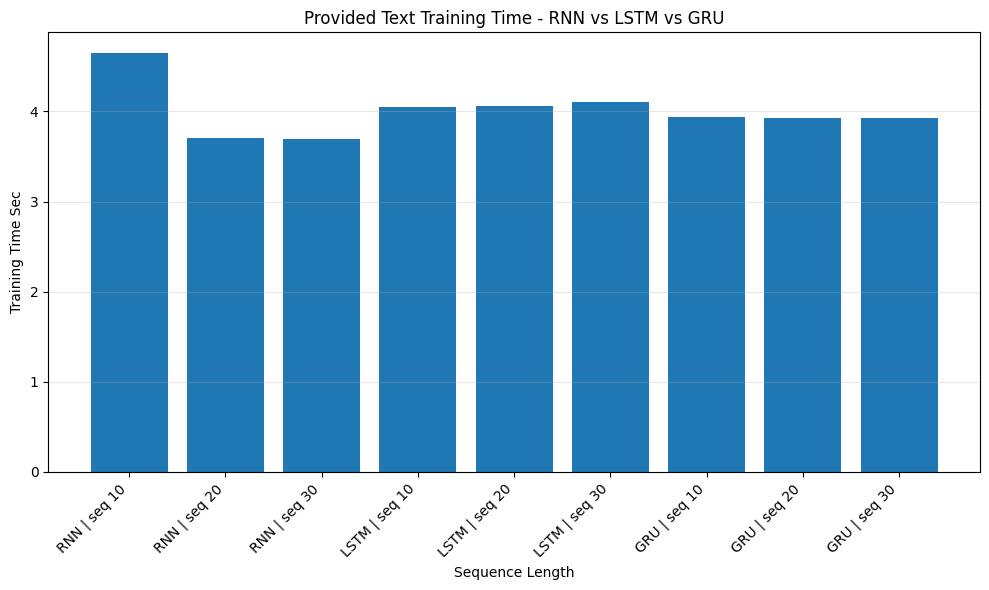

### Final Tiny Shakespeare validation accuracy comparison

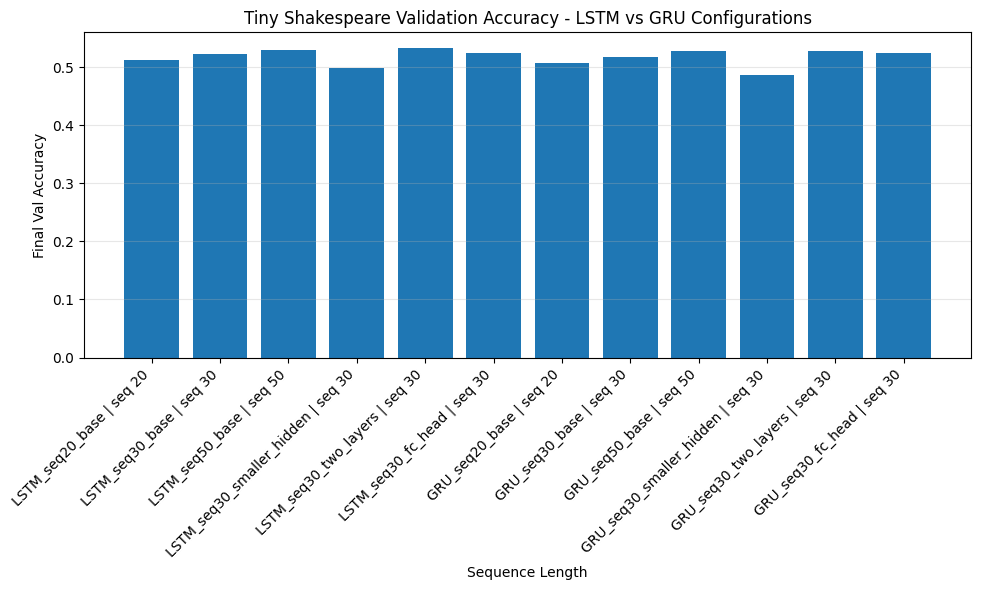

### Final Tiny Shakespeare validation perplexity comparison

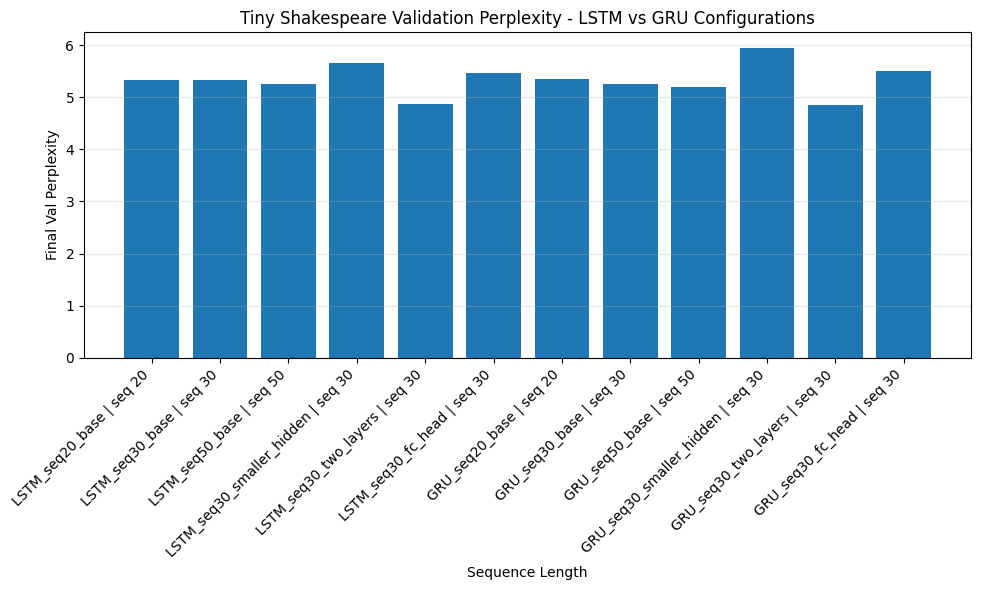

### Final Tiny Shakespeare model size comparison

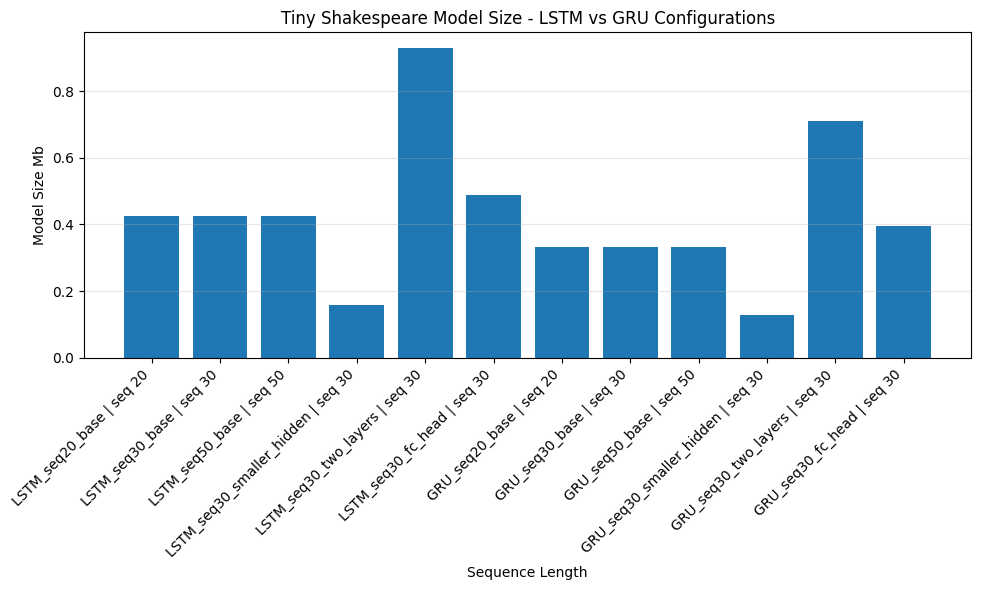

### Final Tiny Shakespeare training time comparison

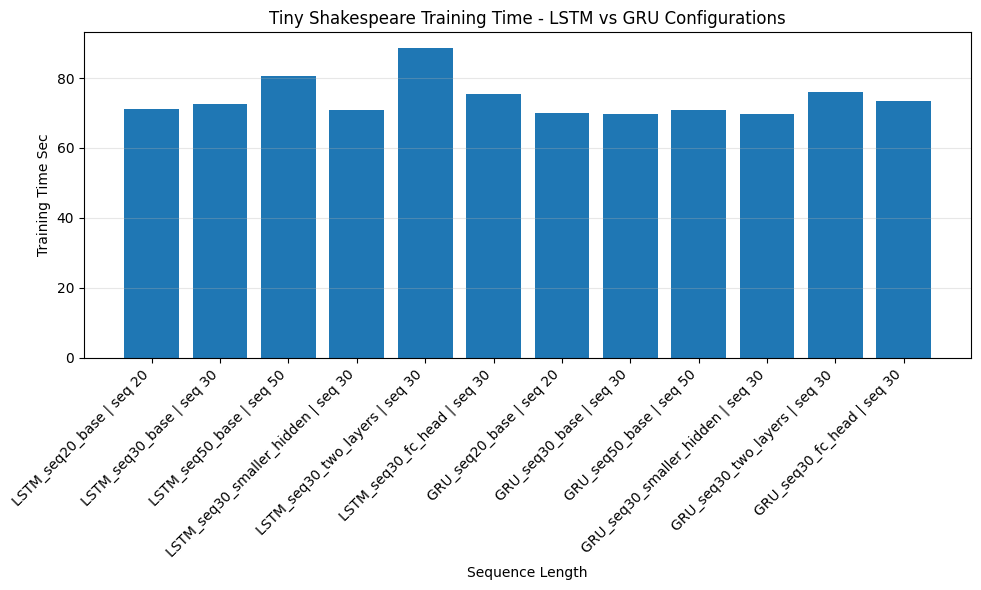

In [19]:
# ===========================================================
# 10. Final comparison and conclusion
# ============================================================

all_results_df = pd.concat(
    [
        p1_rnn_results_df,
        p2_lstm_fixed_results_df,
        p3_gru_fixed_results_df,
        p2_lstm_shakespeare_results_df,
        p3_gru_shakespeare_results_df,
    ],
    ignore_index=True
)

all_history_df = pd.concat(
    [
        p1_rnn_history_df,
        p2_lstm_fixed_history_df,
        p3_gru_fixed_history_df,
        p2_lstm_shakespeare_history_df,
        p3_gru_shakespeare_history_df,
    ],
    ignore_index=True
)

all_samples = (
    p1_rnn_samples
    + p2_lstm_fixed_samples
    + p3_gru_fixed_samples
    + p2_lstm_shakespeare_samples
    + p3_gru_shakespeare_samples
)

save_results_csv(all_results_df, "final_all_results.csv")
save_results_csv(all_history_df, "final_all_training_history.csv")

print_section("Final combined result table")
display_clean_results(all_results_df)

print_section("comparison: Provided Text, RNN vs LSTM vs GRU")
problem1_official_df = all_results_df[
    all_results_df["dataset"] == "Provided Text"
].copy()

display_clean_results(problem1_official_df)
save_results_csv(problem1_official_df, "_problem1_provided_text_results.csv")

print_section("comparison: Tiny Shakespeare, LSTM vs GRU")
problem2_official_df = all_results_df[
    all_results_df["dataset"] == "Tiny Shakespeare"
].copy()

display_clean_results(problem2_official_df)
save_results_csv(problem2_official_df, "official_problem2_tiny_shakespeare_results.csv")

print_section("validation accuracy comparison")
plot_result_bar(
    problem1_official_df,
    x_col="sequence_length",
    y_col="final_val_accuracy",
    group_col="model_type",
    title="Provided Text Validation Accuracy - RNN vs LSTM vs GRU",
    save_name="final_provided_text_validation_accuracy.png",
)

print_section("Final Problem 1 training loss comparison")
plot_result_bar(
    problem1_official_df,
    x_col="sequence_length",
    y_col="final_train_loss",
    group_col="model_type",
    title="Provided Text Final Training Loss - RNN vs LSTM vs GRU",
    save_name="final_provided_text_training_loss.png",
)

print_section("Final Problem 1 model size comparison")
plot_result_bar(
    problem1_official_df,
    x_col="sequence_length",
    y_col="model_size_mb",
    group_col="model_type",
    title="Provided Text Model Size - RNN vs LSTM vs GRU",
    save_name="final_provided_text_model_size.png",
)

print_section("Final Problem 1 training time comparison")
plot_result_bar(
    problem1_official_df,
    x_col="sequence_length",
    y_col="training_time_sec",
    group_col="model_type",
    title="Provided Text Training Time - RNN vs LSTM vs GRU",
    save_name="final_provided_text_training_time.png",
)

print_section("Final Tiny Shakespeare validation accuracy comparison")
plot_result_bar(
    problem2_official_df,
    x_col="sequence_length",
    y_col="final_val_accuracy",
    group_col="config_description",
    title="Tiny Shakespeare Validation Accuracy - LSTM vs GRU Configurations",
    save_name="final_shakespeare_validation_accuracy.png",
)

print_section("Final Tiny Shakespeare validation perplexity comparison")
plot_result_bar(
    problem2_official_df,
    x_col="sequence_length",
    y_col="final_val_perplexity",
    group_col="config_description",
    title="Tiny Shakespeare Validation Perplexity - LSTM vs GRU Configurations",
    save_name="final_shakespeare_perplexity.png",
)

print_section("Final Tiny Shakespeare model size comparison")
plot_result_bar(
    problem2_official_df,
    x_col="sequence_length",
    y_col="model_size_mb",
    group_col="config_description",
    title="Tiny Shakespeare Model Size - LSTM vs GRU Configurations",
    save_name="final_shakespeare_model_size.png",
)

print_section("Final Tiny Shakespeare training time comparison")
plot_result_bar(
    problem2_official_df,
    x_col="sequence_length",
    y_col="training_time_sec",
    group_col="config_description",
    title="Tiny Shakespeare Training Time - LSTM vs GRU Configurations",
    save_name="final_shakespeare_training_time.png",
)